In [1]:
import pandas as pd
from scripts.aux_msa_functions import *
from scipy.spatial.distance import cdist, pdist, squareform
import os
import numpy as np
import torch
from Bio import Phylo
import seaborn as sns
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import re
from scipy.stats import pearsonr
from math import floor,ceil
from scipy import stats
import esm
from patsy import dmatrices
import statsmodels.api as sm
from joblib import Parallel, delayed


torch.set_grad_enabled(True)

In [2]:
pfam_metadata = pd.read_csv("./data/pfam-metadata/pfam_metadata.tsv", delimiter = "\t")

all_metrics_dataframe = pd.read_csv("./untracked-files/sequence_scores_table.tsv", delimiter = "\t")
# all_metrics_dataframe = all_metrics_dataframe.merge(pfam_metadata, left_on = "family", right_on="pfam_id")



### Attention and Sequence-level Scores

OutOfMemoryError: CUDA out of memory. Tried to allocate 140.00 MiB. GPU 1 has a total capacty of 47.40 GiB of which 70.12 MiB is free. Process 3860589 has 2.98 GiB memory in use. Process 3932214 has 3.95 GiB memory in use. Process 126317 has 3.95 GiB memory in use. Process 337991 has 3.81 GiB memory in use. Process 459554 has 1.04 GiB memory in use. Including non-PyTorch memory, this process has 31.54 GiB memory in use. Of the allocated memory 30.53 GiB is allocated by PyTorch, and 721.80 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

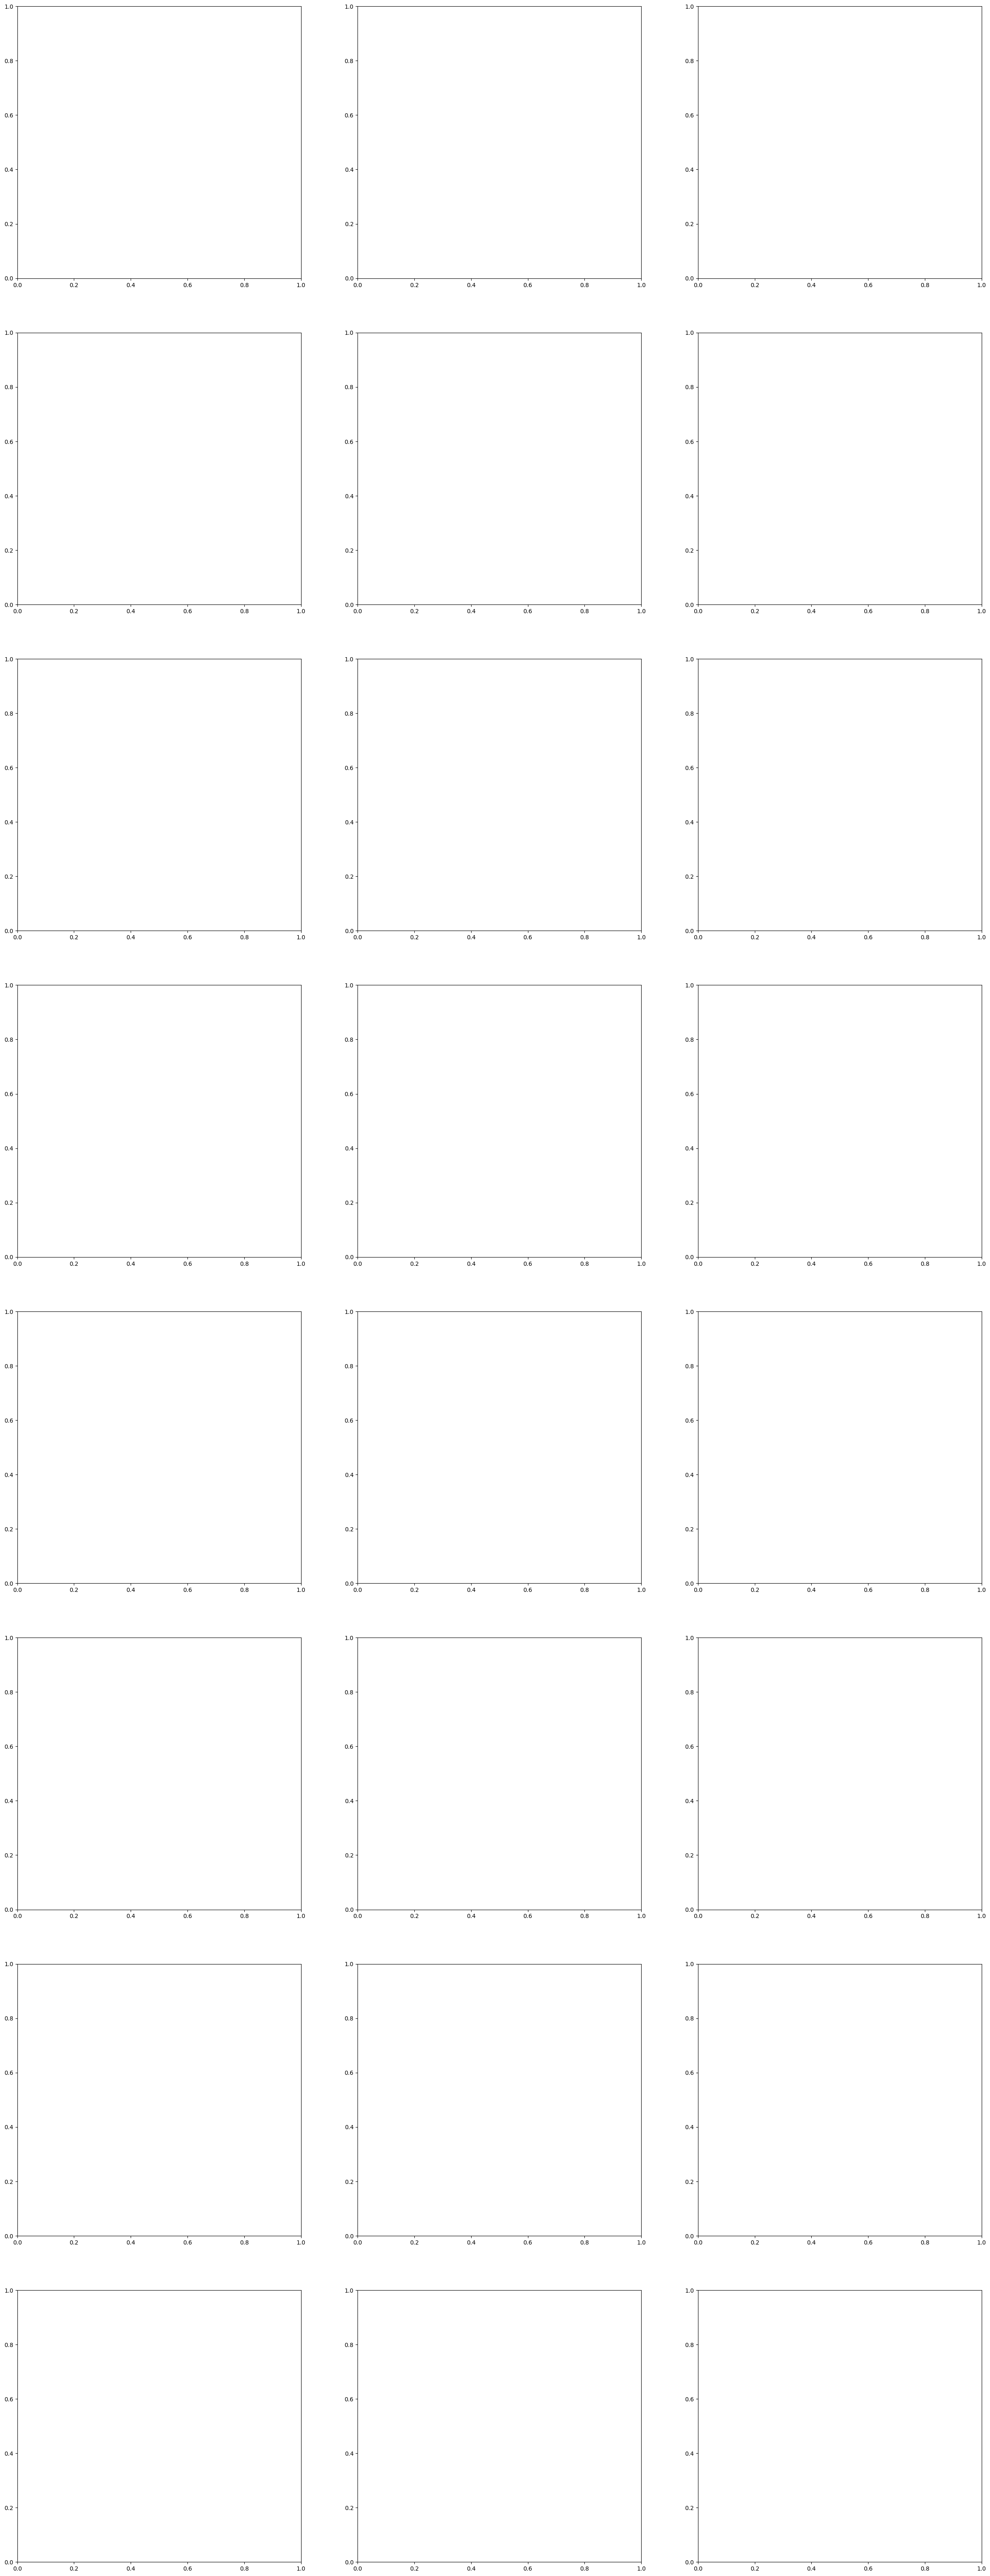

In [4]:
family = "PF00004"
sim_ind = 1
tool = "MSA-1b-logitsprop-static-10-init-seq-0"

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

corr_matrix_hmmer_list = []
corr_matrix_stat_list = []
corr_matrix_plddt_list = []
corr_matrix_nat_dist_list = []
corr_matrix_self_dist_list = []
corr_matrix_rmsd_list = []

all_families_df = pd.DataFrame()

for k, family in enumerate(families):

    torch.cuda.empty_cache()

    all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["family"] == family) & 
                                                      (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                      (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3


    if len(all_metrics_dataframe_fam) > 500:
        # random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
        all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

    sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]
    device = "cuda:1" if torch.cuda.is_available() else "cpu"

    _,_, sequences_tensor = batch_converter([sequences])
    sequences_tensor = sequences_tensor.to(device)

    model_output = model(sequences_tensor, need_head_weights=True)
    column_attns = model_output["col_attentions"][0]

    n_seqs = len(sequences)
    mean_attn = torch.mean(column_attns, axis = [3])

    del model_output, sequences_tensor, column_attns
    torch.cuda.empty_cache()

    mean_attn = torch.mean(mean_attn, axis = [2]).cpu().numpy()
    mean_attn = np.reshape(mean_attn, newshape = (-1,n_seqs), order = 'C')
    mean_attn = np.transpose(mean_attn)

    mean_attn_df = pd.DataFrame(mean_attn, columns = [f"col_attn_{i}" for i in range(mean_attn.shape[1])])
    final_df = pd.concat([mean_attn_df, all_metrics_dataframe_fam], axis = 1)

    all_families_df = pd.concat([all_families_df, final_df]).reset_index(drop = True)

    corr_matrix_hmmer = np.zeros(144)
    corr_matrix_stat = np.zeros(144)
    corr_matrix_plddt = np.zeros(144)
    corr_matrix_nat_dist = np.zeros(144)
    corr_matrix_self_dist = np.zeros(144)
    corr_matrix_rmsd = np.zeros(144)

    for a in range(len(corr_matrix_hmmer)):

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["hmmer_seq_score"]).statistic
        corr_matrix_hmmer[a] = corr

        try:
            corr = pearsonr(final_df[f"col_attn_{a}"], final_df["stat_energy_scores"]).statistic
            corr_matrix_stat[a] = corr
        except:
            pass

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["plddt_scores"]).statistic
        corr_matrix_plddt[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["min_natural_ham_dist_seed"]).statistic
        corr_matrix_nat_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["max_self_ham_distance"]).statistic
        corr_matrix_self_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["rmsd"]).statistic
        corr_matrix_rmsd[a] = corr

    corr_matrix_hmmer = np.reshape(corr_matrix_hmmer, newshape = (12,12), order = "C")
    corr_matrix_stat = np.reshape(corr_matrix_stat, newshape = (12,12), order = "C")
    corr_matrix_plddt = np.reshape(corr_matrix_plddt, newshape = (12,12), order = "C")
    corr_matrix_nat_dist = np.reshape(corr_matrix_nat_dist, newshape = (12,12), order = "C")
    corr_matrix_self_dist = np.reshape(corr_matrix_self_dist, newshape = (12,12), order = "C")
    corr_matrix_rmsd = np.reshape(corr_matrix_rmsd, newshape = (12,12), order = "C")

    corr_matrix_hmmer_list.append(corr_matrix_hmmer)
    corr_matrix_stat_list.append(corr_matrix_stat)
    corr_matrix_plddt_list.append(corr_matrix_plddt)
    corr_matrix_nat_dist_list.append(corr_matrix_nat_dist)
    corr_matrix_self_dist_list.append(corr_matrix_self_dist)
    corr_matrix_rmsd_list.append(corr_matrix_rmsd)

    # im = axes[i][j].imshow(corr_matrix_hmmer, vmin = -1, vmax = 1, cmap = "RdBu_r")
    # plt.colorbar(im, ax=axes[i][j])
    # axes[i][j].set_title(f"{family}")


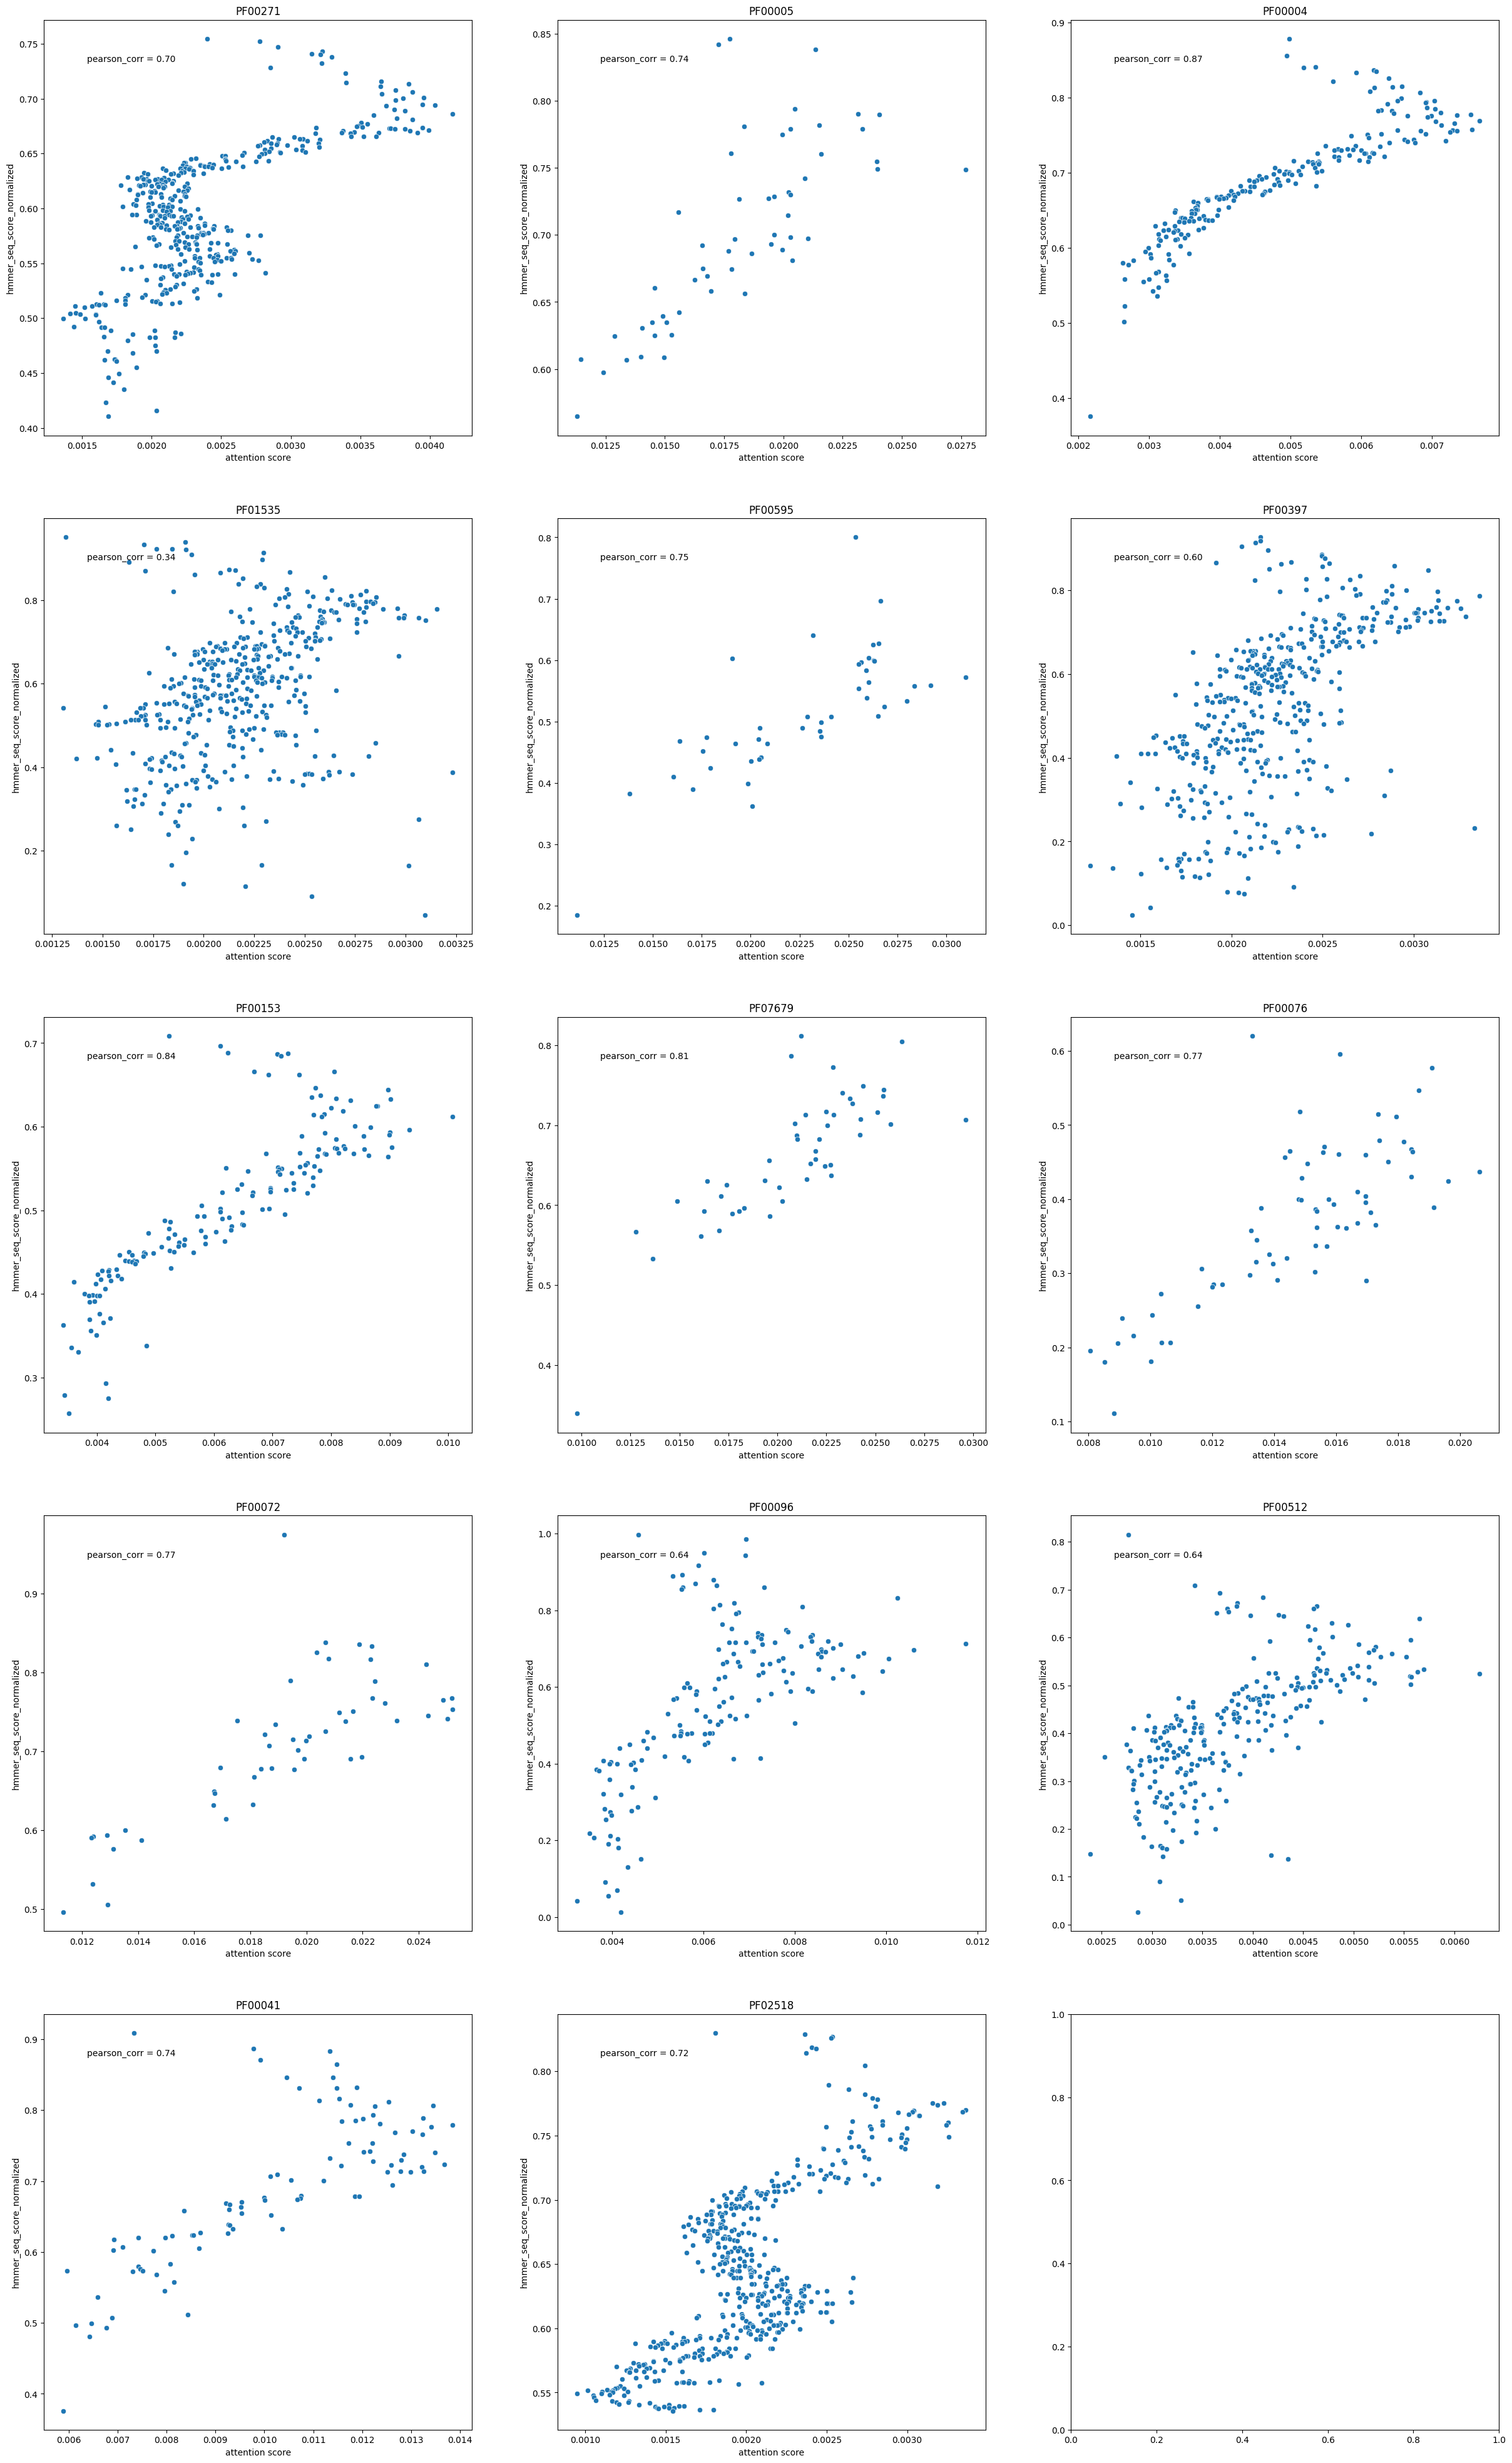

In [ ]:

head_number = 1
score = "hmmer_seq_score_normalized"

families = all_families_df["pfam_id"].unique()

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

for k, fam in enumerate(families):

    i = floor(k/3)
    j = k % 3
    
    all_families_df_fam = all_families_df.loc[all_families_df["family"] == fam, :].reset_index(drop = True)
    sns.scatterplot(data = all_families_df_fam, x = f"col_attn_{head_number}", y = score, ax = axes[i][j])
    axes[i][j].set_title(families[k])
    axes[i][j].set_xlabel("attention score")
    axes[i][j].set_ylabel(score)
    pearson_corr = pearsonr(all_families_df_fam[f"col_attn_{head_number}"], all_families_df_fam[score])
    axes[i][j].annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 10)



plt.savefig(f"attn_head_{head_number}_vs_{score}.png")
# all_families_df_fam = all_families_df.loc[all_families_df["family"] == fam, :].reset_index(drop = True)

# pearson_corr = pearsonr(x =all_families_df_fam[f"col_attn_{head_number}"], y=all_families_df_fam[score])
# plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 10)

In [ ]:
mean_hmmer_corr = np.stack(corr_matrix_hmmer_list).mean(axis=0)
mean_stat_corr = np.stack(corr_matrix_stat_list).mean(axis=0)
mean_plddt_corr = np.stack(corr_matrix_plddt_list).mean(axis=0)
mean_nat_dist_corr = np.stack(corr_matrix_nat_dist_list).mean(axis=0)
mean_self_dist_corr = np.stack(corr_matrix_self_dist_list).mean(axis=0)
mean_rmsd_corr = np.stack(corr_matrix_rmsd_list).mean(axis=0)

Text(0.5, 1.0, 'mean_rmsd_corr')

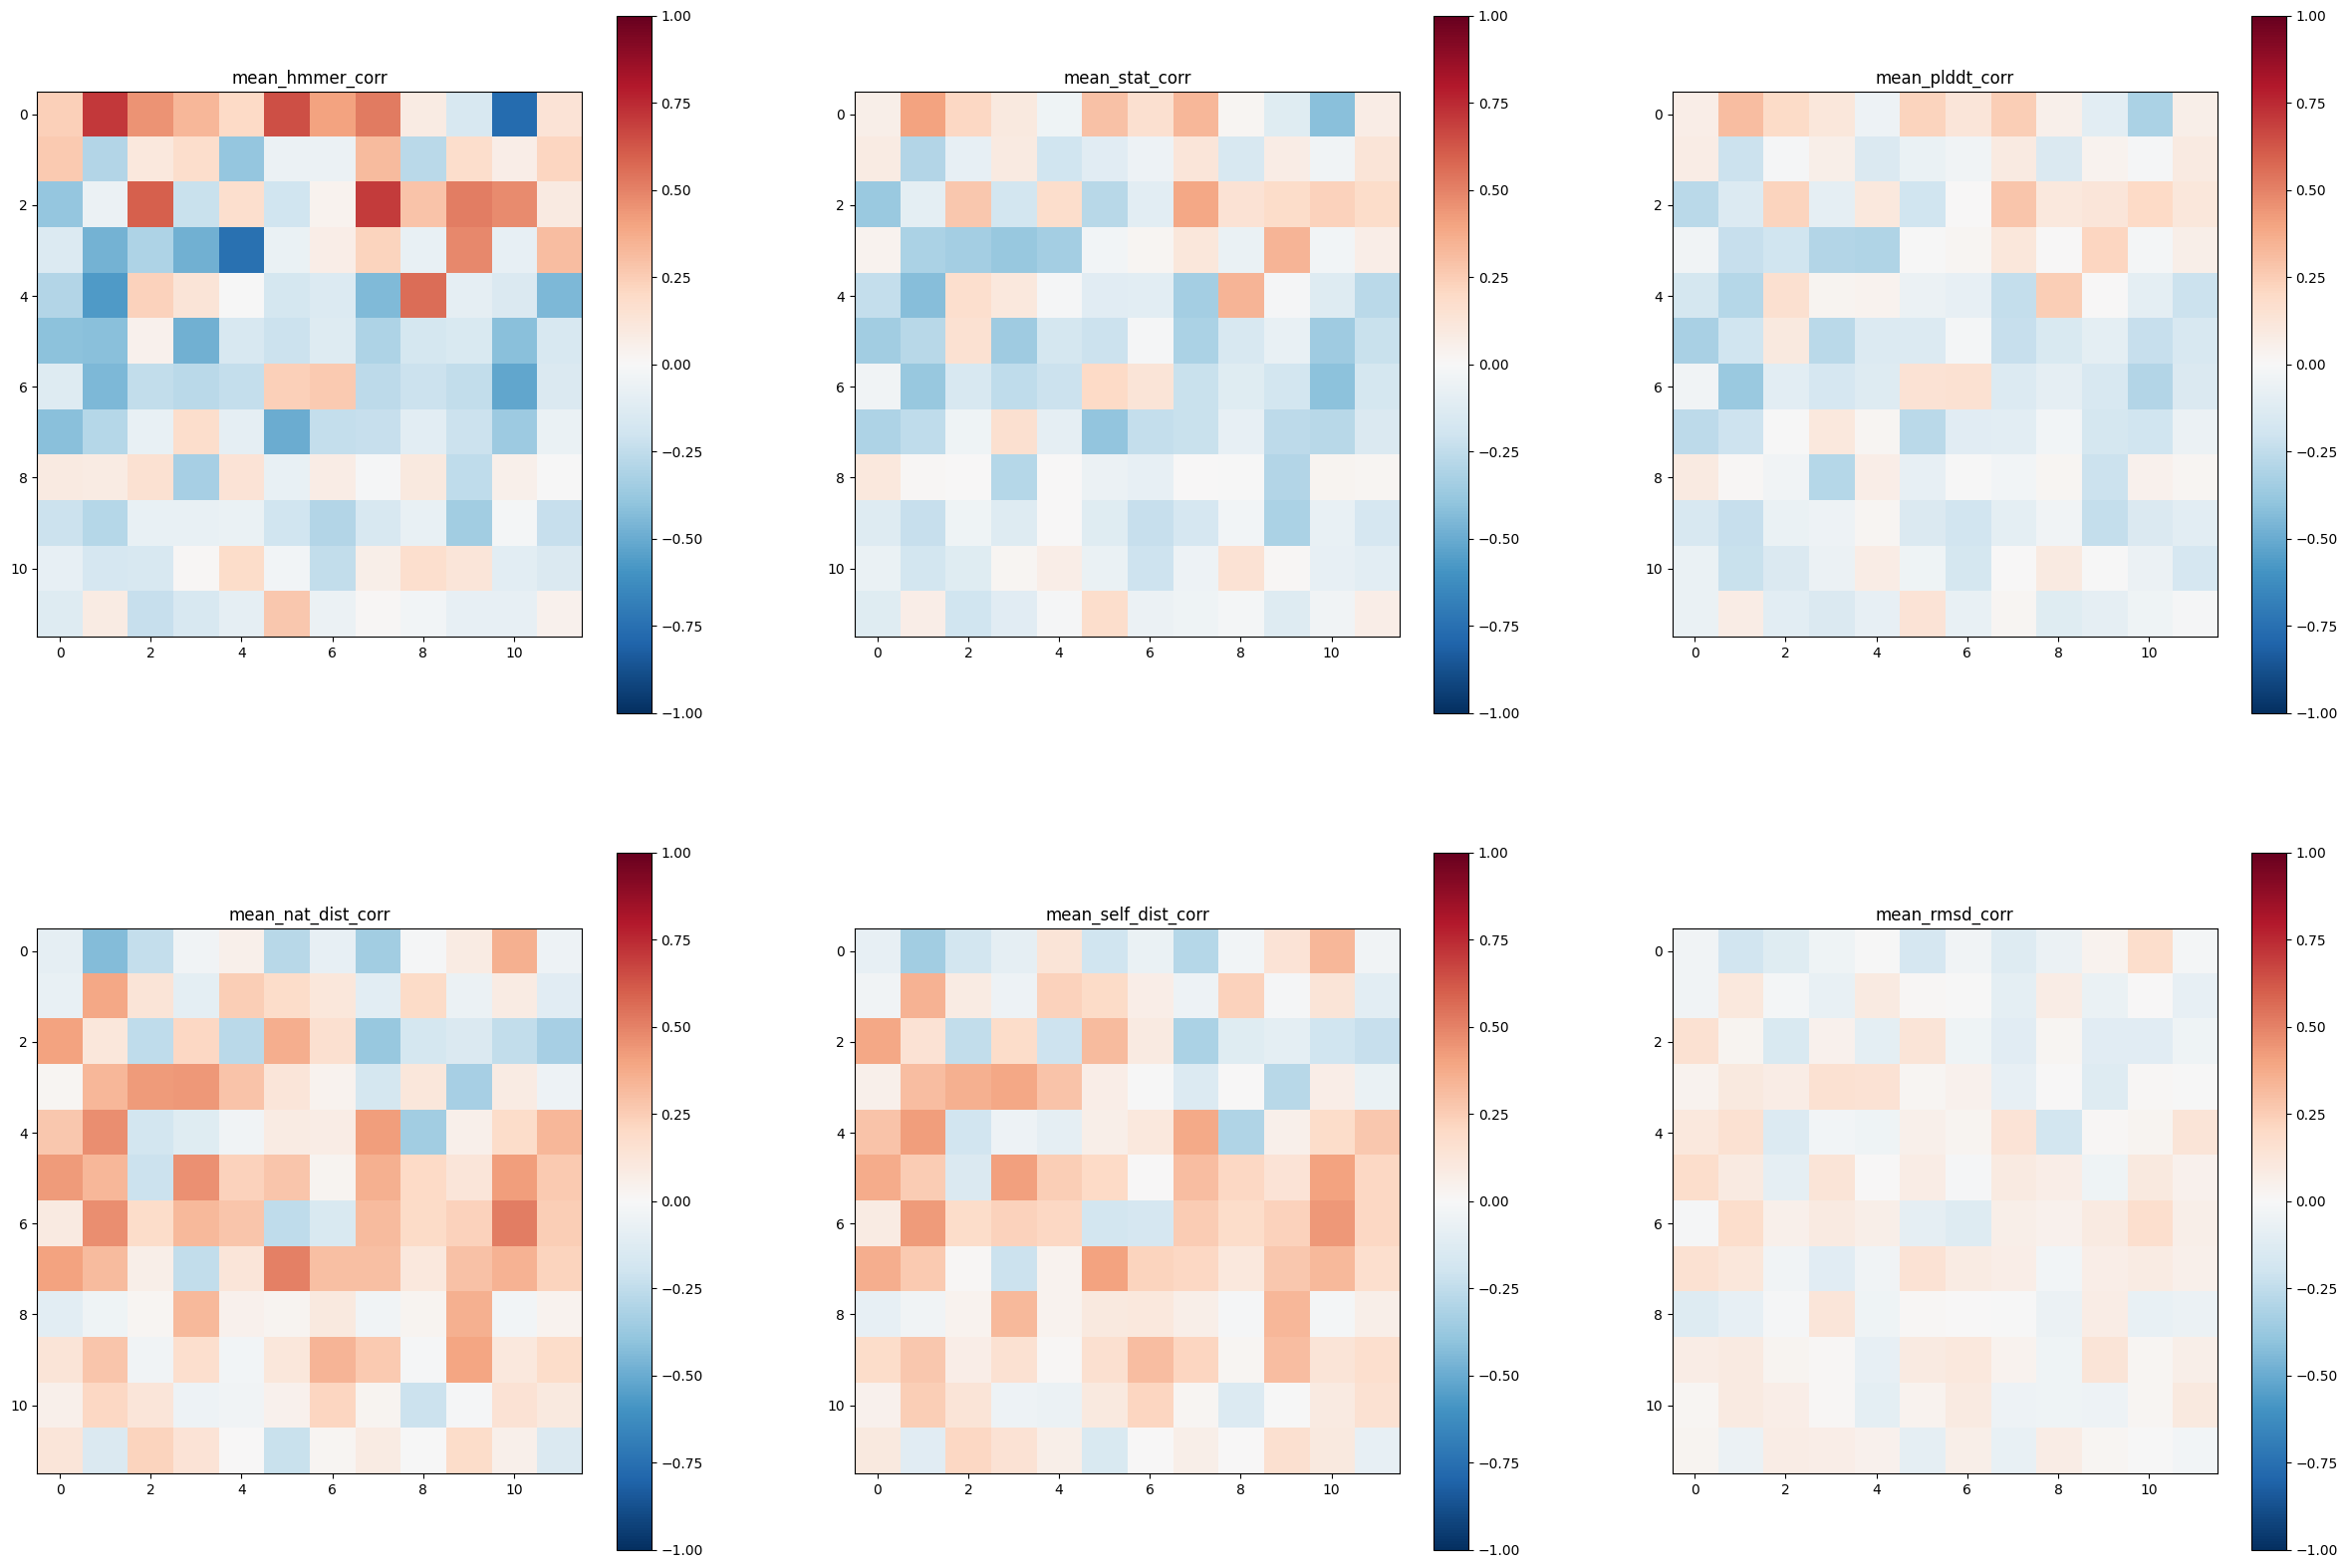

In [ ]:

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

im = axes[0][0].imshow(mean_hmmer_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][0])
axes[0][0].set_title(f"mean_hmmer_corr")

im = axes[0][1].imshow(mean_stat_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][1])
axes[0][1].set_title(f"mean_stat_corr")

im = axes[0][2].imshow(mean_plddt_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][2])
axes[0][2].set_title(f"mean_plddt_corr")

im = axes[1][0].imshow(mean_nat_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][0])
axes[1][0].set_title(f"mean_nat_dist_corr")

im = axes[1][1].imshow(mean_self_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][1])
axes[1][1].set_title(f"mean_self_dist_corr")

im = axes[1][2].imshow(mean_rmsd_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][2])
axes[1][2].set_title(f"mean_rmsd_corr")

# plt.savefig("column_attn_corrs_all_metrics.jpeg")


Text(0.5, 0.9, 'pearson_corr = 0.95')

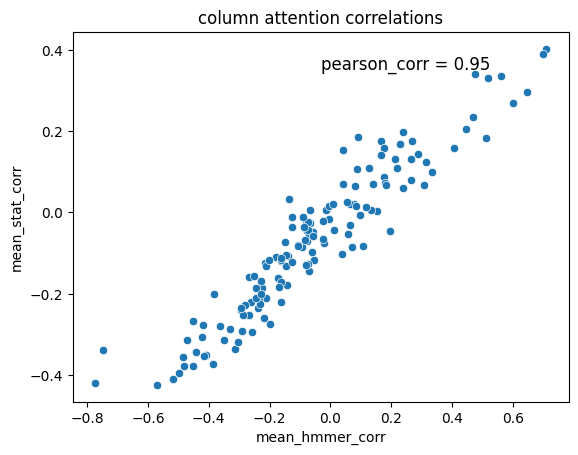

In [ ]:
sns.scatterplot(x =mean_hmmer_corr.flatten(), y=mean_stat_corr.flatten())
plt.xlabel("mean_hmmer_corr")
plt.ylabel("mean_stat_corr")
plt.title("column attention correlations")

pearson_corr = pearsonr(x =mean_hmmer_corr.flatten(), y=mean_stat_corr.flatten())
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.5,0.9), xycoords = "axes fraction", fontsize = 12)

# plt.savefig("column_attn_scatter_hmmer_vs_nat_dist.jpeg")

Text(0.1, 0.9, 'pearson_corr = 0.91')

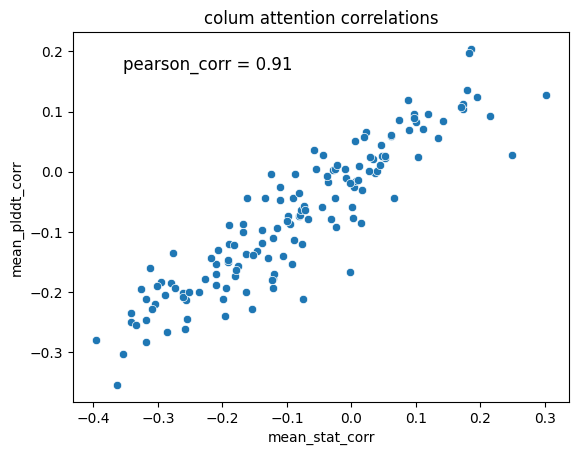

In [ ]:
sns.scatterplot(x =mean_stat_corr.flatten(), y=mean_plddt_corr.flatten())
plt.xlabel("mean_stat_corr")
plt.ylabel("mean_plddt_corr")
plt.title("colum attention correlations")

pearson_corr = pearsonr(x =mean_stat_corr.flatten(), y=mean_plddt_corr.flatten())
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 12)

# plt.savefig("column_attn_scatter_hmmer_vs_stat.jpeg")

## Attention Scores vs Patristic Distances

In [3]:
def reorder_seqs(tree_root, all_nat_seqs_dict):

    output = []
    
    def reorder_seqs_recur(tree_root, all_nat_seqs_dict):
    
        b = tree_root.clades
        
        if len(b)>0:
            for clade in b:
               reorder_seqs_recur(clade, all_nat_seqs_dict) 
        else:
            output.append((tree_root.name,all_nat_seqs_dict[tree_root.name]))

    reorder_seqs_recur(tree_root, all_nat_seqs_dict)

    return output

### Calculate pairwise patristic and hamming distance

In [ ]:
pat_dist_dict = {}

families = list(all_metrics_dataframe["family"].unique())

for k, family in enumerate(families):

    pat_family_dict = {}

    torch.cuda.empty_cache()

    MSA_filename_seed = f"./data/protein-families-msa-seed/{family}_seed.fasta"
    nat_seqs = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(MSA_filename_seed, "fasta")]

    tree_path = f"./data/seed-trees/{family}_seed.newick"
    tree = Phylo.read(tree_path,"newick")
    tree.root_at_midpoint()
    
    for i in range(len(nat_seqs)):
            
            for j in range(i, len(nat_seqs)):

                seqname_i = nat_seqs[i][0]
                seqname_j = nat_seqs[j][0]

                pat_dist = tree.distance(seqname_i,seqname_j)
                pat_family_dict[(seqname_i, seqname_j)] = pat_dist
                pat_family_dict[(seqname_j, seqname_i)] = pat_dist
                
    pat_dist_dict[family] = pat_family_dict


In [4]:
import pickle as pkl

with open("pairwise_patristic_distances.pkl", "rb") as handle:
    pat_dist_dict = pkl.load(handle)

### NN model

In [5]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

class AttentionNet(nn.Module):

    def __init__(self, input_size, n_layers, hid_dim, drop_prob):

        super().__init__()

        self.input_size = input_size
        self.n_layers = n_layers
        self.hid_dim = hid_dim
        self.input_layer = nn.Linear(input_size, hid_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hid_dim, hid_dim) for _ in range(self.n_layers)])
        self.output_layer = nn.Linear(hid_dim, 1)
        self.dropout = nn.Dropout(drop_prob)
        self.relu = nn.ReLU()
        self.sigmoid =  nn.Sigmoid()

    def forward(self, x):

        x = self.input_layer(x)
        x = self.sigmoid(x)
        for layer in self.hidden_layers:
            x = layer(x)
            x = self.sigmoid(x)
            x= self.dropout(x)
        x = self.output_layer(x)
        x = self.sigmoid(x)

        return x
    
class AttentionNetSmall(nn.Module):

    def __init__(self, input_size, hid_dim, drop_prob):

        super().__init__()

        self.input_size = input_size
        self.hid_dim = hid_dim
        self.input_layer = nn.Linear(input_size, hid_dim)
        self.output_layer = nn.Linear(hid_dim, 1)
        self.dropout = nn.Dropout(drop_prob)
        self.relu = nn.ReLU()
        self.sigmoid =  nn.Sigmoid()

    def forward(self, x):

        x = self.input_layer(x)
        x = self.sigmoid(x)
        x = self.output_layer(x)
        x = self.sigmoid(x)

        return x

In [6]:
sim_ind = 1
tools = ["nat"]
SEED = 42
train_size = 0.7


### Per-family model training

In [ ]:
from scripts.select_gpu import get_free_gpu

def make_train_test_sets(tool,family,seed_number):

    rng_2 = np.random.default_rng(seed=seed_number)
    train_idxs = rng_2.choice(depth, size=n_train, replace=False)
    split_mask = np.zeros(depth, dtype=bool)
    split_mask[train_idxs] = True

    attns_train, attns_test = attns_mean_on_cols_symm[:, :, split_mask, :][:, :, :, split_mask], attns_mean_on_cols_symm[:, :, ~split_mask, :][:, :, :, ~split_mask]
    dists_train, dists_test = hamming_distances[split_mask, :][:, split_mask], hamming_distances[~split_mask, :][:, ~split_mask]
    pat_dists_train, pat_dists_test = pat_dists[split_mask, :][:, split_mask], pat_dists[~split_mask, :][:, ~split_mask]
    
    n_rows_train, n_rows_test = attns_train.shape[-1], attns_test.shape[-1]
    triu_indices_train = np.triu_indices(n_rows_train)
    triu_indices_test = np.triu_indices(n_rows_test)
    
    attns_train = attns_train[..., triu_indices_train[0], triu_indices_train[1]]
    attns_test = attns_test[..., triu_indices_test[0], triu_indices_test[1]]
    dists_train = dists_train[triu_indices_train]
    dists_test = dists_test[triu_indices_test]
    pat_dists_train = pat_dists_train[triu_indices_train]
    pat_dists_test = pat_dists_test[triu_indices_test]
    
    attns_train = attns_train.transpose(2, 0, 1).reshape(-1, n_layers * n_heads)
    attns_test = attns_test.transpose(2, 0, 1).reshape(-1, n_layers * n_heads)

    # del model_output, sequences_tensor, attns_mean_on_cols_symm
    torch.cuda.empty_cache()

    train_df = pd.DataFrame(attns_train, columns = [f"col_attn_{i}" for i in range(144)])
    train_df["tool"] = tool
    train_df["pat_dist"] = pat_dists_train
    train_df["norm_pat_dist"] = train_df["pat_dist"]/pat_dists.max()
    train_df["ham_dist"] = dists_train
    train_df["family"] = family
    train_df["sim_ind"] = sim_ind
    train_df["seed_number"] = seed_number

    # train_df = train_df.loc[train_df["ham_dist"] > 0, :].reset_index(drop=True)

    test_df = pd.DataFrame(attns_test, columns = [f"col_attn_{i}" for i in range(144)])
    test_df["tool"] = tool
    test_df["pat_dist"] = pat_dists_test
    test_df["norm_pat_dist"] = test_df["pat_dist"]/pat_dists.max()
    test_df["ham_dist"] = dists_test
    test_df["family"] = family
    test_df["sim_ind"] = sim_ind
    test_df["seed_number"] = seed_number

    # test_df = test_df.loc[test_df["ham_dist"] > 0, :].reset_index(drop=True)

    return (train_df, test_df)
    
families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

gpu = int(get_free_gpu())
device = f"cuda:{gpu}"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

n_layers = n_heads = 12

all_families_train_df = pd.DataFrame()
all_families_test_df = pd.DataFrame()

corr_matrix_pat_list = []

families = [
    "PF00004",
    "PF00005",
    "PF00041",
    "PF00072",
    "PF00076",
    "PF00096",
    "PF00153",
    "PF00271",
    "PF00397",
    "PF00512",
    "PF00595",
    "PF01535",
    "PF02518",
    "PF07679",
    "PF13354",   
    # "PF01356",
    # "PF03440",
    # "PF04008",
    # "PF06351",
    # "PF06355",
    # "PF16747",
    # "PF18648"
]

for tool in tools:

    for k, family in enumerate(families):

        torch.cuda.empty_cache()

        MSA_filename_seed = f"./data/protein-families-msa-seed/{family}_seed.fasta"
        nat_seqs = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(MSA_filename_seed, "fasta")]

        all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["family"] == family) & 
                                                        (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                        (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)
                
        if len(all_metrics_dataframe_fam) > 500:
            random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
            all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

        sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]
        # device = "cuda:1" if torch.cuda.is_available() else "cpu"

        _,_, sequences_tensor = batch_converter([sequences])
        sequences_tensor = sequences_tensor.to(device)

        with torch.no_grad():
            model_output = model(sequences_tensor, need_head_weights=True)
            attns_mean_on_cols_symm = model_output["col_attentions"].cpu().numpy()[0, ...].mean(axis=2)
            attns_mean_on_cols_symm += attns_mean_on_cols_symm.transpose(0, 1, 3, 2)

        depth = len(sequences)
        n_train = int(train_size * depth)

        tree_path = f"./data/seed-trees/{family}_seed.newick"
        tree = Phylo.read(tree_path,"newick")
        tree.root_at_midpoint()

        reordered_seqs = reorder_seqs(tree.clade, dict(nat_seqs))
        mapping_dict = {f"seq{i}":reordered_seqs[i][0] for i in range(len(nat_seqs))}

        hamming_distances = squareform(pdist(sequences_tensor.cpu().numpy()[0, :, 1:], "hamming"))

        pat_dists = np.zeros((depth,depth))

        for i in range(len(sequences)):
            for j in range(i, len(sequences)):

                seqname_i = sequences[i][0]
                seqname_j = sequences[j][0]

                if tool != "nat":
                    pat_dist = pat_dist_dict[family][(mapping_dict[seqname_i],mapping_dict[seqname_j])]
                else:
                    pat_dist = pat_dist_dict[family][(seqname_i,seqname_j)]
                
                pat_dists[i,j] = pat_dist
                pat_dists[j,i] = pat_dist        
        
        
        rng = np.random.default_rng(seed=SEED)
        random_seeds = rng.choice(range(10000), size=10, replace=False)

        results = Parallel(n_jobs=10)(delayed(make_train_test_sets)(tool, family, seed_number) for seed_number in random_seeds)

        train_df = pd.concat([item[0] for item in results]).reset_index(drop = True)
        test_df = pd.concat([item[1] for item in results]).reset_index(drop = True)
        
        all_families_train_df = pd.concat([all_families_train_df, train_df]).reset_index(drop = True)
        all_families_test_df = pd.concat([all_families_test_df, test_df]).reset_index(drop = True)
        


In [ ]:
with open(f"attention_train_df_{train_size}.pkl","wb") as handle:
    pkl.dump(all_families_train_df, handle)

with open(f"attention_test_df_{train_size}.pkl","wb") as handle:
    pkl.dump(all_families_test_df, handle)

In [ ]:
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from scripts.select_gpu import get_free_gpu
from sklearn.metrics import r2_score
import pickle as pkl

def fit_attention_model_NN(family, train_df, test_df, seed_number, attention_cols, response_col):

    hidden_size = 24
    num_epochs = {"small":100, "large":50}
    batch_size = {"small":50, "large": 50}
    learning_rate = 0.1
    n_layers = 2
    dropout_prob = 0.2

    large_families = ["PF00004","PF00271","PF00397", "PF00512", "PF02518","PF01535"]

    train_df_seed = train_df.loc[train_df["seed_number"] == seed_number, :].reset_index(drop = True)
    test_df_seed = test_df.loc[test_df["seed_number"] == seed_number, :].reset_index(drop = True)

    X_train = torch.tensor(train_df_seed[attention_cols].values, dtype=torch.float32)
    y_train = torch.tensor(train_df_seed[response_col].values, dtype=torch.float32)

    X_test = torch.tensor(test_df_seed[attention_cols].values, dtype=torch.float32)
    y_test = torch.tensor(test_df_seed[response_col].values, dtype=torch.float32)

    gpu = int(get_free_gpu())
    device = torch.device(f'cuda:{gpu}' if torch.cuda.is_available() else 'cpu')

    if family in large_families:
        model = AttentionNet(len(attention_cols), n_layers, hidden_size, drop_prob=dropout_prob).to(device)
        num_epochs = num_epochs["large"]
        batch_size = batch_size["large"]
    else:
        model = AttentionNetSmall(len(attention_cols), hid_dim=24, drop_prob=0).to(device)
        num_epochs = num_epochs["small"]
        batch_size = batch_size["small"]

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)
    
    

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    for param in model.parameters():
        assert param.requires_grad   

    n_samples_train = X_train.shape[0]
    n_samples_test = X_test.shape[0]

    n_total_steps = len(train_loader)

    train_epoch_losses = []
    test_epoch_losses = []

    train_epoch_r2_scores = []
    test_epoch_r2_scores = []


    for epoch in range(num_epochs):

        train_epoch_outputs = []
        train_labels = []

        model.train()

        for i, (data, labels) in enumerate(train_loader):  

            data = data.to(device)
            labels = labels.to(device)
            
            outputs = model(data).squeeze(1)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_epoch_outputs.append(outputs)
            train_labels.append(labels)
                    
            # if (i+1) % 10 == 0:
            #     print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

        scheduler.step()

        train_epoch_outputs = torch.cat(train_epoch_outputs)
        train_labels = torch.cat(train_labels)

        with torch.no_grad():
            train_epoch_loss = criterion(train_epoch_outputs, train_labels).item()
            train_epoch_r2 = r2_score(train_labels.cpu().numpy(), train_epoch_outputs.cpu().numpy())

        train_epoch_losses.append(train_epoch_loss)
        train_epoch_r2_scores.append(train_epoch_r2)

        model.eval()

        test_epoch_outputs = []
        test_labels = []

        with torch.no_grad():

            for data, labels in test_loader:

                data = data.to(device)
                labels = labels.to(device)
                outputs = model(data).squeeze(1)

                test_epoch_outputs.append(outputs)
                test_labels.append(labels)
            
            test_epoch_outputs = torch.cat(test_epoch_outputs)
            test_labels = torch.cat(test_labels)

            test_epoch_loss = criterion(test_epoch_outputs, test_labels).item()
            test_epoch_r2 = r2_score(test_labels.cpu().numpy(), test_epoch_outputs.cpu().numpy())

            test_epoch_losses.append(test_epoch_loss)
            test_epoch_r2_scores.append(test_epoch_r2)

    del(model,outputs,optimizer)

    with torch.no_grad():    
        train_epoch_outputs = train_epoch_outputs.cpu().numpy()
        test_epoch_outputs = test_epoch_outputs.cpu().numpy()

        train_labels = train_labels.cpu().numpy()
        test_labels = test_labels.cpu().numpy()
        
    torch.cuda.empty_cache()
    
    regr_results = ({
        "tool": tool,   
        "family":family, 
        "seed_number":seed_number ,
        "RMSE (training)": np.linalg.norm(train_labels - train_epoch_outputs) / np.sqrt(n_samples_train),
        "RMSE (test)": np.linalg.norm(test_labels - test_epoch_outputs) / np.sqrt(n_samples_test),
        "MAE (training)": np.sum(np.abs(train_labels - train_epoch_outputs)) / len(train_labels),
        "MAE (test)": np.sum(np.abs(test_labels - test_epoch_outputs)) / len(test_labels),
        "R^2 (test)" : r2_score(y_true=test_labels, y_pred = test_epoch_outputs),
        "R^2 (train)" : r2_score(y_true=train_labels, y_pred = train_epoch_outputs),
        "train_epoch_losses":train_epoch_losses,
        "test_epoch_losses":test_epoch_losses,
        "train_epoch_r2_scores":train_epoch_r2_scores,
        "test_epoch_r2_scores": test_epoch_r2_scores,
        # "R^2 (small test)" : r2_score(small_test, small_pred_test),
        # "R^2 (large test)" : r2_score(large_test, large_pred_test),
        # "Pearson (test)" : pearsonr(test_labels, test_epoch_outputs).statistic
        })
    
    return regr_results

In [ ]:
from scipy.special import expit, logit
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from patsy import dmatrices

epsilon = 1e-6

def safe_logit(y):
    y = np.clip(y, epsilon, 1 - epsilon)
    return logit(y)


def fit_attention_model(family, train_df, test_df, seed_number, attention_cols, response_col):

    train_df_seed = train_df.loc[train_df["seed_number"] == seed_number, :].reset_index(drop = True)
    test_df_seed = test_df.loc[test_df["seed_number"] == seed_number, :].reset_index(drop = True)


    df_train = train_df_seed[attention_cols + [response_col]]
    df_test = test_df_seed[attention_cols + [response_col]]

    formula = f"{response_col} ~ " + " + ".join(attention_cols)
    y_train, X_train = dmatrices(formula, df_train, return_type="dataframe")
    y_test, X_test = dmatrices(formula, df_test, return_type="dataframe")


    binom_model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
    binom_model_results = binom_model.fit(maxiter=500, tol=1e-9)

    y_pred_test = binom_model_results.predict(X_test)
    y_pred_train = binom_model_results.predict(X_train)

    y_train = y_train[response_col]
    y_test = y_test[response_col]

    n_samples_train = len(y_train)
    n_samples_test = len(y_test)

    regr_results = {   
        "tool": tool,   
        "family":family, 
        "seed_number":seed_number ,
        "RMSE (training)": np.linalg.norm(y_train - y_pred_train) / np.sqrt(n_samples_train),
        "RMSE (test)": np.linalg.norm(y_test - y_pred_test) / np.sqrt(n_samples_test),
        "MAE (training)": np.sum(np.abs(y_train - y_pred_train)) / n_samples_train,
        "MAE (test)": np.sum(np.abs(y_test - y_pred_test)) / n_samples_test,
        "R^2 (test)" : r2_score(y_test, y_pred_test),
        # "R^2 (small test)" : r2_score(small_test, small_pred_test),
        # "R^2 (large test)" : r2_score(large_test, large_pred_test),
        "Pearson (test)" : pearsonr(y_test, y_pred_test).statistic
        }
    
    return regr_results

In [ ]:
with open(f"./untracked-files/attention_train_df_{train_size}.pkl","rb") as handle:
    all_families_train_df = pkl.load(handle)

all_families_train_df = all_families_train_df.loc[all_families_train_df["ham_dist"] > 0, :]

with open(f"./untracked-files/attention_test_df_{train_size}.pkl","rb") as handle:
    all_families_test_df = pkl.load(handle)

all_families_test_df = all_families_test_df.loc[all_families_test_df["ham_dist"] > 0, :]

In [ ]:
attention_cols = [f"col_attn_{i}" for i in range(144)]
response_col = "norm_pat_dist"

regr_results_df = []

families = [
    "PF00004",
    "PF00005",
    "PF00041",
    "PF00072",
    "PF00076",
    "PF00096",
    "PF00153",
    "PF00271",
    "PF00397",
    "PF00512",
    "PF00595",
    "PF01535",
    "PF07679",
    "PF13354",
    "PF02518",
    # "PF01356",
    # "PF03440",
    # "PF04008",
    # "PF06351",
    # "PF06355",
    # "PF16747",
    # "PF18648"
]


for tool in tools:

    for family in families:
            
            print(family)

            all_families_train_df_fam = all_families_train_df.loc[(all_families_train_df["family"] == family) & (all_families_train_df["tool"] == tool), :].reset_index(drop = True)
            all_families_test_df_fam = all_families_test_df.loc[(all_families_test_df["family"] == family) & (all_families_test_df["tool"] == tool), :].reset_index(drop = True)

            seed_numbers = list(all_families_train_df_fam["seed_number"].unique())

            results = Parallel(n_jobs=20)(delayed(fit_attention_model)(family, all_families_train_df_fam, all_families_test_df_fam, seed_number, attention_cols, response_col) for seed_number in seed_numbers)
            # results = [fit_attention_model_NN(family, all_families_train_df_fam, all_families_test_df_fam, seed_numbers[0], attention_cols, response_col)]

            torch.cuda.empty_cache()
            
            regr_results_df += results


regr_results_df = pd.DataFrame(regr_results_df)

PF00004
PF00005
PF00041
PF00072
PF00076
PF00096
PF00153
PF00271
PF00397


/home/samant/miniconda/envs/msa-explore/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


PF00512
PF00595
PF01535
PF07679
PF13354
PF02518


### Across-family model

In [18]:
from scripts.select_gpu import get_free_gpu

def make_train_test_sets_whole_families(tool,family):
        
        torch.cuda.empty_cache()

        print(family)
        
        MSA_filename_seed = f"./data/protein-families-msa-seed/{family}_seed.fasta"
        nat_seqs = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(MSA_filename_seed, "fasta")]

        all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["family"] == family) & 
                                                        (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                        (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)
                
        if len(all_metrics_dataframe_fam) > 300:
            random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
            all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

        sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]

        _,_, sequences_tensor = batch_converter([sequences])
        sequences_tensor = sequences_tensor.to(device)

        with torch.no_grad():
            model_output = model(sequences_tensor, need_head_weights=True)
            attns_mean_on_cols_symm = model_output["col_attentions"].cpu().numpy()[0, ...].mean(axis=2)
            attns_mean_on_cols_symm += attns_mean_on_cols_symm.transpose(0, 1, 3, 2)

        depth = len(sequences)

        tree_path = f"./data/seed-trees/{family}_seed.newick"
        tree = Phylo.read(tree_path,"newick")
        tree.root_at_midpoint()

        reordered_seqs = reorder_seqs(tree.clade, dict(nat_seqs))
        mapping_dict = {f"seq{i}":reordered_seqs[i][0] for i in range(len(nat_seqs))}

        hamming_distances = squareform(pdist(sequences_tensor.cpu().numpy()[0, :, 1:], "hamming"))

        pat_dists = np.zeros((depth,depth))

        for i in range(len(sequences)):
            for j in range(i, len(sequences)):

                seqname_i = sequences[i][0]
                seqname_j = sequences[j][0]

                if tool != "nat":
                    pat_dist = pat_dist_dict[family][(mapping_dict[seqname_i],mapping_dict[seqname_j])]
                else:
                    pat_dist = pat_dist_dict[family][(seqname_i,seqname_j)]
                
                pat_dists[i,j] = pat_dist
                pat_dists[j,i] = pat_dist

        n_rows = attns_mean_on_cols_symm.shape[-1]
        triu_indices = np.triu_indices(n_rows)
        
        attns_mean_on_cols_symm = attns_mean_on_cols_symm[..., triu_indices[0], triu_indices[1]]
        hamming_distances = hamming_distances[triu_indices]
        pat_dists = pat_dists[triu_indices]
        
        attns_mean_on_cols_symm = attns_mean_on_cols_symm.transpose(2, 0, 1).reshape(-1, n_layers * n_heads)

        # del model_output, sequences_tensor, attns_mean_on_cols_symm
        torch.cuda.empty_cache()

        train_df = pd.DataFrame(attns_mean_on_cols_symm, columns = [f"col_attn_{i}" for i in range(144)])
        train_df["tool"] = tool
        train_df["pat_dist"] = pat_dists
        train_df["norm_pat_dist"] = train_df["pat_dist"]/pat_dists.max()
        train_df["ham_dist"] = hamming_distances
        train_df["family"] = family
        train_df["sim_ind"] = sim_ind
        
        return (train_df)

families = [
    "PF00004",
    "PF00005",
    "PF00041",
    "PF00072",
    "PF00076",
    "PF00096",
    "PF00153",
    "PF00271",
    "PF00397",
    "PF00512",
    "PF00595",
    "PF01535",
    "PF02518",
    "PF07679",
    "PF13354",   
]

tool = "nat"

gpu = int(get_free_gpu())
device = f"cuda:{gpu}"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

n_layers = n_heads = 12

train_families = families[:12]
test_families = families[12:]

# results = Parallel(n_jobs=10)(delayed(make_train_test_sets_whole_families)(tool, family) for family in train_families)
# train_df = pd.concat([item for item in results]).reset_index(drop = True)

results = Parallel(n_jobs=10)(delayed(make_train_test_sets_whole_families)(tool, family) for family in test_families)
test_df = pd.concat([item for item in results]).reset_index(drop = True)

# all_families_train_df = pd.DataFrame()
# all_families_train_df = pd.concat([all_families_train_df, train_df]).reset_index(drop = True)

all_families_test_df = pd.DataFrame()
all_families_test_df = pd.concat([all_families_test_df, test_df]).reset_index(drop = True)

PF02518
PF07679
PF13354


In [ ]:
with open(f"attention_train_df_whole_fams.pkl","wb") as handle:
    pkl.dump(all_families_train_df, handle)

with open(f"attention_test_df_whole_fams.pkl","wb") as handle:
    pkl.dump(all_families_test_df, handle)

In [11]:
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from scripts.select_gpu import get_free_gpu
from sklearn.metrics import r2_score
import pickle as pkl

def fit_attention_model_NN_whole_families(train_df, test_df, attention_cols, response_col):

    hidden_size = 24
    num_epochs = 25
    batch_size = 50
    learning_rate = 0.1
    n_layers = 2
    dropout_prob = 0.2

    X_train = torch.tensor(train_df[attention_cols].values, dtype=torch.float32)
    y_train = torch.tensor(train_df[response_col].values, dtype=torch.float32)

    X_test = torch.tensor(test_df[attention_cols].values, dtype=torch.float32)
    y_test = torch.tensor(test_df[response_col].values, dtype=torch.float32)

    gpu = int(get_free_gpu())
    device = torch.device(f'cuda:{gpu}' if torch.cuda.is_available() else 'cpu')

    model = AttentionNet(len(attention_cols), n_layers, hidden_size, drop_prob=dropout_prob).to(device)

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

    test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)
    
    

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.97)

    for param in model.parameters():
        assert param.requires_grad   

    n_samples_train = X_train.shape[0]
    n_samples_test = X_test.shape[0]

    n_total_steps = len(train_loader)

    train_epoch_losses = []
    test_epoch_losses = []

    train_epoch_r2_scores = []
    test_epoch_r2_scores = []


    for epoch in range(num_epochs):

        train_epoch_outputs = []
        train_labels = []

        model.train()

        for i, (data, labels) in enumerate(train_loader):  

            data = data.to(device)
            labels = labels.to(device)
            
            outputs = model(data).squeeze(1)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_epoch_outputs.append(outputs)
            train_labels.append(labels)
                    
            if (i+1) % 10 == 0:
                print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

        scheduler.step()

        train_epoch_outputs = torch.cat(train_epoch_outputs)
        train_labels = torch.cat(train_labels)

        with torch.no_grad():
            train_epoch_loss = criterion(train_epoch_outputs, train_labels).item()
            train_epoch_r2 = r2_score(train_labels.cpu().numpy(), train_epoch_outputs.cpu().numpy())

        train_epoch_losses.append(train_epoch_loss)
        train_epoch_r2_scores.append(train_epoch_r2)

        model.eval()

        test_epoch_outputs = []
        test_labels = []

        with torch.no_grad():

            for data, labels in test_loader:

                data = data.to(device)
                labels = labels.to(device)
                outputs = model(data).squeeze(1)

                test_epoch_outputs.append(outputs)
                test_labels.append(labels)
            
            test_epoch_outputs = torch.cat(test_epoch_outputs)
            test_labels = torch.cat(test_labels)

            test_epoch_loss = criterion(test_epoch_outputs, test_labels).item()
            test_epoch_r2 = r2_score(test_labels.cpu().numpy(), test_epoch_outputs.cpu().numpy())

            test_epoch_losses.append(test_epoch_loss)
            test_epoch_r2_scores.append(test_epoch_r2)

    del(model,outputs,optimizer)

    with torch.no_grad():    
        train_epoch_outputs = train_epoch_outputs.cpu().numpy()
        test_epoch_outputs = test_epoch_outputs.cpu().numpy()

        train_labels = train_labels.cpu().numpy()
        test_labels = test_labels.cpu().numpy()

    train_labels = pd.Series(train_labels)
    test_labels = pd.Series(test_labels)

    train_epoch_outputs = pd.Series(train_epoch_outputs)
    test_epoch_outputs = pd.Series(test_epoch_outputs)
        
    torch.cuda.empty_cache()

    all_regr_results = []

    for family in test_df["family"].unique():

        test_labels_fam = test_labels.loc[test_df["family"] == family]
        test_epoch_outputs_fam = test_epoch_outputs.loc[test_df["family"] == family]
    
        all_regr_results += [{
            "tool": tool,   
            "family":family, 
            "RMSE (test)": np.linalg.norm(test_labels_fam - test_epoch_outputs_fam) / np.sqrt(n_samples_test),
            "MAE (test)": np.sum(np.abs(test_labels_fam - test_epoch_outputs_fam)) / len(test_labels_fam),
            "R^2 (test)" : r2_score(y_true=test_labels_fam, y_pred = test_epoch_outputs_fam),
            # "train_epoch_losses":train_epoch_losses,
            # "test_epoch_losses":test_epoch_losses,
            # "train_epoch_r2_scores":train_epoch_r2_scores,
            # "test_epoch_r2_scores": test_epoch_r2_scores,
            }]
    
    return all_regr_results

In [7]:
with open(f"./untracked-files/attention_train_df_whole_fams.pkl","rb") as handle:
    all_families_train_df = pkl.load(handle)

all_families_train_df = all_families_train_df.loc[all_families_train_df["ham_dist"] > 0, :]

with open(f"./untracked-files/attention_test_df_whole_fams.pkl","rb") as handle:
    all_families_test_df = pkl.load(handle)

all_families_test_df = all_families_test_df.loc[all_families_test_df["ham_dist"] > 0, :]

In [12]:
attention_cols = [f"col_attn_{i}" for i in range(144)]
response_col = "norm_pat_dist"

regr_results_df = []

for tool in tools:

    all_families_train_df_fam = all_families_train_df.loc[(all_families_train_df["tool"] == tool), :].reset_index(drop = True)
    all_families_test_df_fam = all_families_test_df.loc[(all_families_test_df["tool"] == tool), :].reset_index(drop = True)

    results = fit_attention_model_NN_whole_families(all_families_train_df_fam, all_families_test_df_fam, attention_cols, response_col)

    torch.cuda.empty_cache()
    
    regr_results_df += results


regr_results_df = pd.DataFrame(regr_results_df)

Epoch [1/25], Step [10/7621], Loss: 0.0194
Epoch [1/25], Step [20/7621], Loss: 0.0155
Epoch [1/25], Step [30/7621], Loss: 0.0123
Epoch [1/25], Step [40/7621], Loss: 0.0257
Epoch [1/25], Step [50/7621], Loss: 0.0158
Epoch [1/25], Step [60/7621], Loss: 0.0147
Epoch [1/25], Step [70/7621], Loss: 0.0219
Epoch [1/25], Step [80/7621], Loss: 0.0232
Epoch [1/25], Step [90/7621], Loss: 0.0274
Epoch [1/25], Step [100/7621], Loss: 0.0241
Epoch [1/25], Step [110/7621], Loss: 0.0144
Epoch [1/25], Step [120/7621], Loss: 0.0183
Epoch [1/25], Step [130/7621], Loss: 0.0296
Epoch [1/25], Step [140/7621], Loss: 0.0187
Epoch [1/25], Step [150/7621], Loss: 0.0161
Epoch [1/25], Step [160/7621], Loss: 0.0218
Epoch [1/25], Step [170/7621], Loss: 0.0189
Epoch [1/25], Step [180/7621], Loss: 0.0128
Epoch [1/25], Step [190/7621], Loss: 0.0195
Epoch [1/25], Step [200/7621], Loss: 0.0212
Epoch [1/25], Step [210/7621], Loss: 0.0159
Epoch [1/25], Step [220/7621], Loss: 0.0181
Epoch [1/25], Step [230/7621], Loss: 0.01

In [13]:
regr_results_df

,tool,family,RMSE (test),MAE (test),R^2 (test)
0,nat,PF02518,0.127713,0.104778,0.405768
1,nat,PF07679,0.010221,0.088365,0.296555
2,nat,PF13354,0.016505,0.091812,0.390603


In [10]:
dist = "ham"

regr_results_df_NN = pd.read_csv(f"NN_attn_fit_{dist}_dist_metrics_0.7_train.tsv", sep = "\t")
regr_results_df_logistic = pd.read_csv(f"logistic_attn_fit_{dist}_dist_metrics_0.7_train.tsv", sep = "\t")

# regr_results_df_NN_med = pd.read_csv(f"NN_attn_fit_{dist}_dist_metrics_0.5_train.tsv", sep = "\t")
# regr_results_df_logistic_med = pd.read_csv(f"logistic_attn_fit_{dist}_dist_metrics_0.5_train.tsv", sep = "\t")

# regr_results_df_NN_small = pd.read_csv(f"NN_attn_fit_{dist}_dist_metrics_0.2_train.tsv", sep = "\t")
# regr_results_df_logistic_small = pd.read_csv(f"logistic_attn_fit_{dist}_dist_metrics_0.2_train.tsv", sep = "\t")


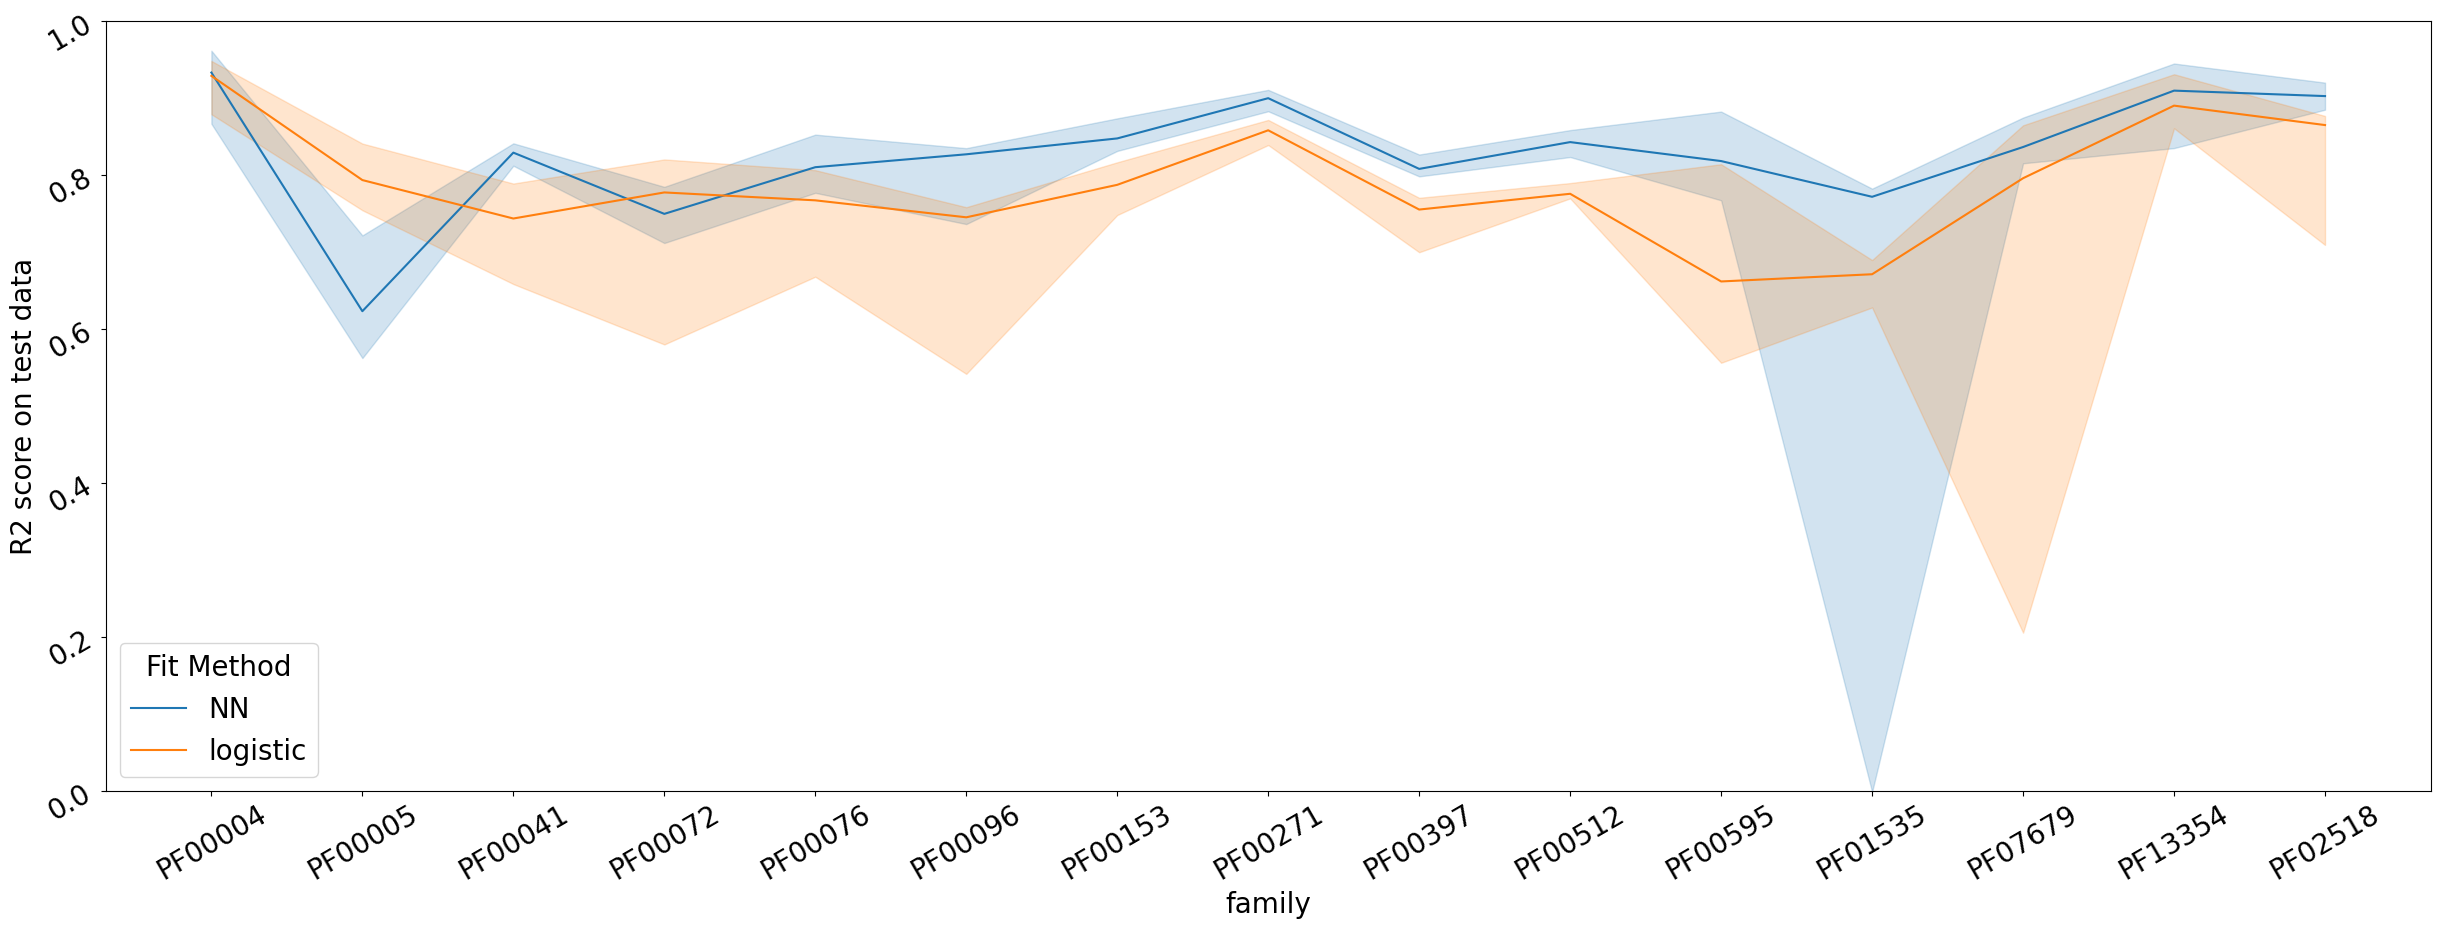

In [12]:
NN_agg = regr_results_df_NN[["family","R^2 (test)"]].groupby(by = "family").agg("mean").reset_index()
logistic_agg = regr_results_df_logistic[["family","R^2 (test)"]].groupby(by = "family").agg("mean").reset_index()

# NN_agg_med = regr_results_df_NN_med[["family","R^2 (test)"]].groupby(by = "family").agg("mean").reset_index()
# logistic_agg_med = regr_results_df_logistic_med[["family","R^2 (test)"]].groupby(by = "family").agg("mean").reset_index()

# NN_agg_small = regr_results_df_NN_small[["family","R^2 (test)"]].groupby(by = "family").agg("mean").reset_index()
# logistic_agg_small = regr_results_df_logistic_small[["family","R^2 (test)"]].groupby(by = "family").agg("mean").reset_index()

fig, axes = plt.subplots(figsize = (30,10))

sns.lineplot(data=regr_results_df_NN, x = "family", y = "R^2 (test)", ax = axes, label = "NN", estimator="median")
sns.lineplot(data=regr_results_df_logistic, x = "family", y = "R^2 (test)", ax = axes, label = "logistic", estimator="median")

# sns.lineplot(data=regr_results_df_NN_med, x = "family", y = "R^2 (test)", ax = axes, label = "NN_med", estimator="median")
# sns.lineplot(data=regr_results_df_logistic_med, x = "family", y = "R^2 (test)", ax = axes, label = "logistic_med", estimator="median")

# sns.lineplot(data=regr_results_df_NN_small, x = "family", y = "R^2 (test)", ax = axes, label = "NN_small", estimator="median")
# sns.lineplot(data=regr_results_df_logistic_small, x = "family", y = "R^2 (test)", ax = axes, label = "logistic_small", estimator="median")

plt.legend(title = "Fit Method", title_fontsize = 20, fontsize = 20)
axes.set_xlabel(axes.get_xlabel(), size = 20)
axes.set_ylabel("R2 score on test data", size = 20)
axes.tick_params(axis='both', labelsize=20, labelrotation = 30)
axes.set_ylim(0,1)
plt.savefig("NN_vs_logistic_pat_dist_fit.jpeg")

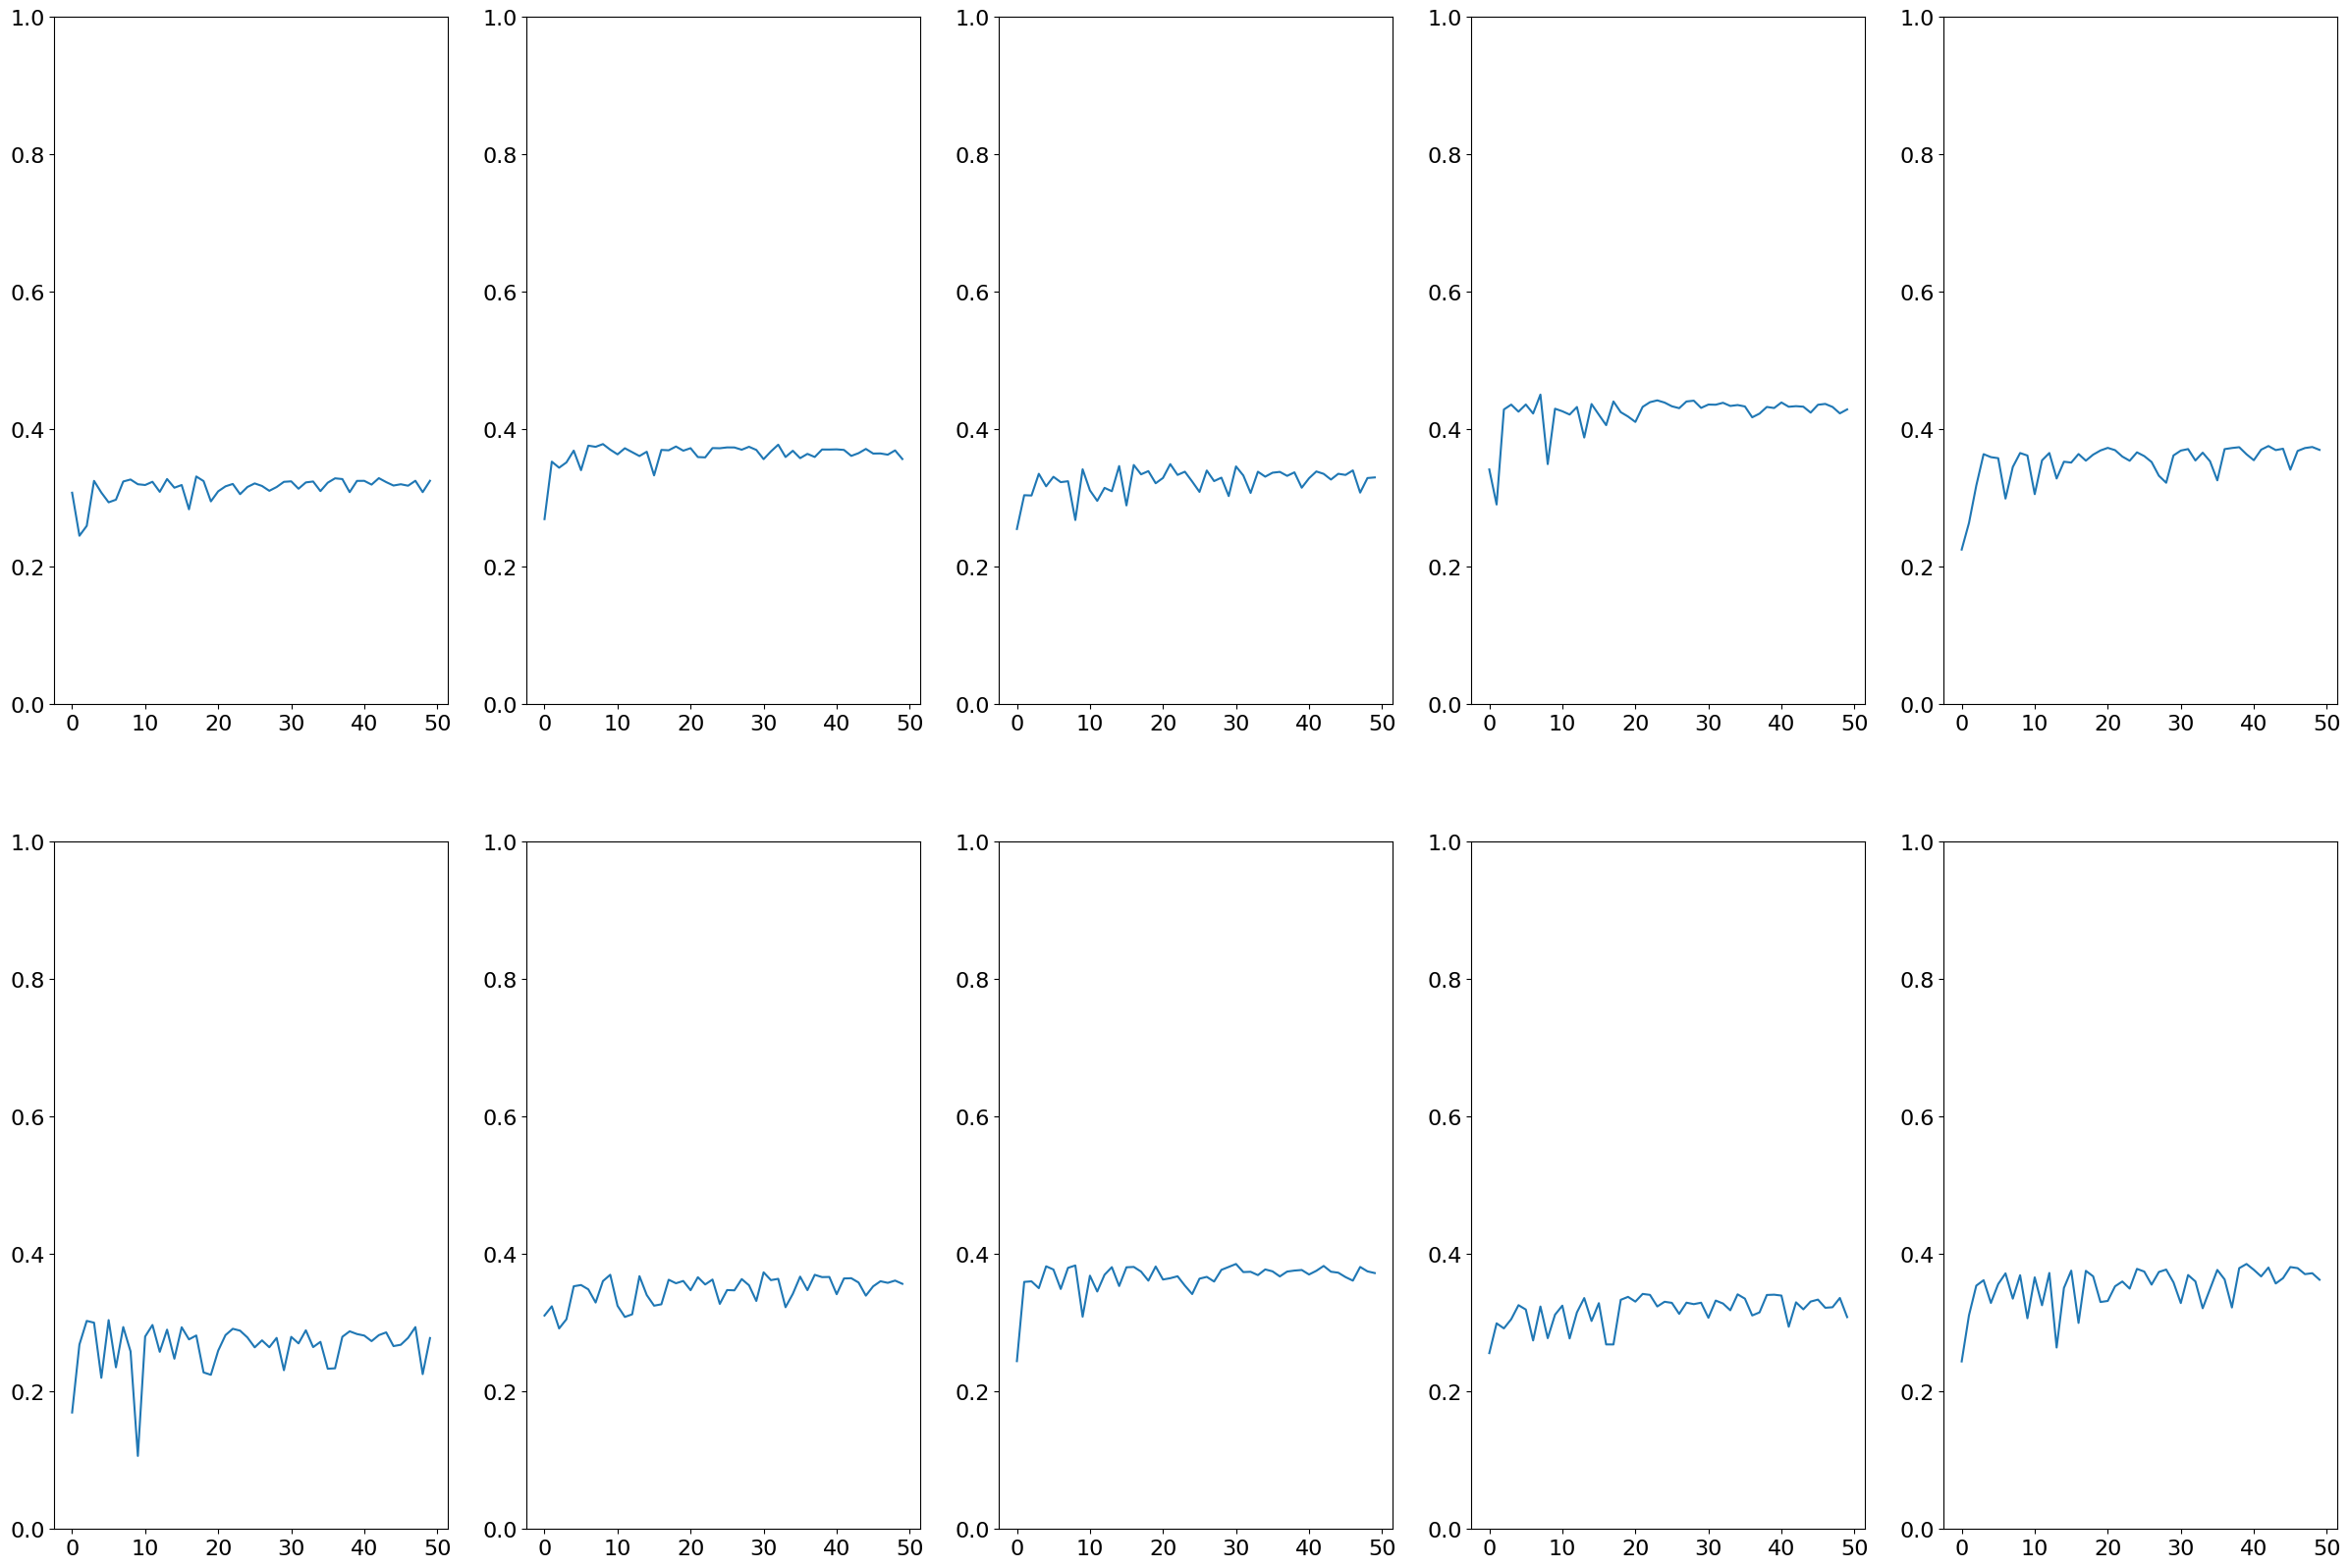

In [155]:
fig, axes = plt.subplots(2,5, figsize = (30,20))

for k in range(10):

    i = int(k / 5)
    j = k % 5

    axes[i][j].plot(list(regr_results_df["test_epoch_r2_scores"])[k])
    axes[i][j].set_ylim(0,1)

In [38]:
all_families_train_df.loc[all_families_train_df["family"] == "PF00005",:]

,col_attn_0,col_attn_1,col_attn_2,col_attn_3,col_attn_4,col_attn_5,col_attn_6,col_attn_7,col_attn_8,col_attn_9,...,col_attn_141,col_attn_142,col_attn_143,tool,pat_dist,norm_pat_dist,ham_dist,family,sim_ind,seed_number
8610,0.088141,0.059320,0.096008,0.038907,0.048826,0.188118,0.024103,0.078722,0.054013,0.211624,...,0.041750,0.116218,0.185639,nat,0.00000,0.000000,0.000000,PF00005,1,859
8611,0.064735,0.061415,0.044795,0.099609,0.078432,0.107434,0.086279,0.090697,0.060617,0.049771,...,0.095656,0.050453,0.022152,nat,2.91097,0.527160,0.737226,PF00005,1,859
8612,0.045016,0.057106,0.071755,0.055787,0.046823,0.166964,0.044974,0.057677,0.062791,0.076675,...,0.024789,0.055345,0.198272,nat,1.28587,0.232864,0.562044,PF00005,1,859
8613,0.046117,0.050867,0.039450,0.049464,0.051015,0.082100,0.041899,0.051448,0.036551,0.037206,...,0.115462,0.053271,0.018676,nat,3.30099,0.597790,0.751825,PF00005,1,859
8614,0.044049,0.035822,0.030697,0.028593,0.053006,0.064489,0.039918,0.035126,0.026115,0.028167,...,0.043660,0.028690,0.007473,nat,3.47059,0.628503,0.759124,PF00005,1,859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9265,0.036494,0.040118,0.040995,0.045733,0.039560,0.036228,0.044239,0.044921,0.049712,0.043197,...,0.036328,0.043698,0.041198,nat,4.94609,0.895708,0.766423,PF00005,1,8582
9266,0.038332,0.034675,0.028565,0.041578,0.039525,0.031227,0.046710,0.039458,0.044790,0.027127,...,0.044312,0.036845,0.028408,nat,3.99294,0.723098,0.817518,PF00005,1,8582
9267,0.048364,0.087466,0.260195,0.046939,0.008062,0.284491,0.027269,0.066224,0.205354,0.320922,...,0.030735,0.070810,0.121167,nat,0.00000,0.000000,0.000000,PF00005,1,8582
9268,0.047612,0.053331,0.048592,0.055271,0.036175,0.030589,0.047777,0.049623,0.057430,0.047576,...,0.052072,0.052885,0.054390,nat,4.81013,0.871086,0.700730,PF00005,1,8582


Text(0, 0.5, 'R^2 (test)')

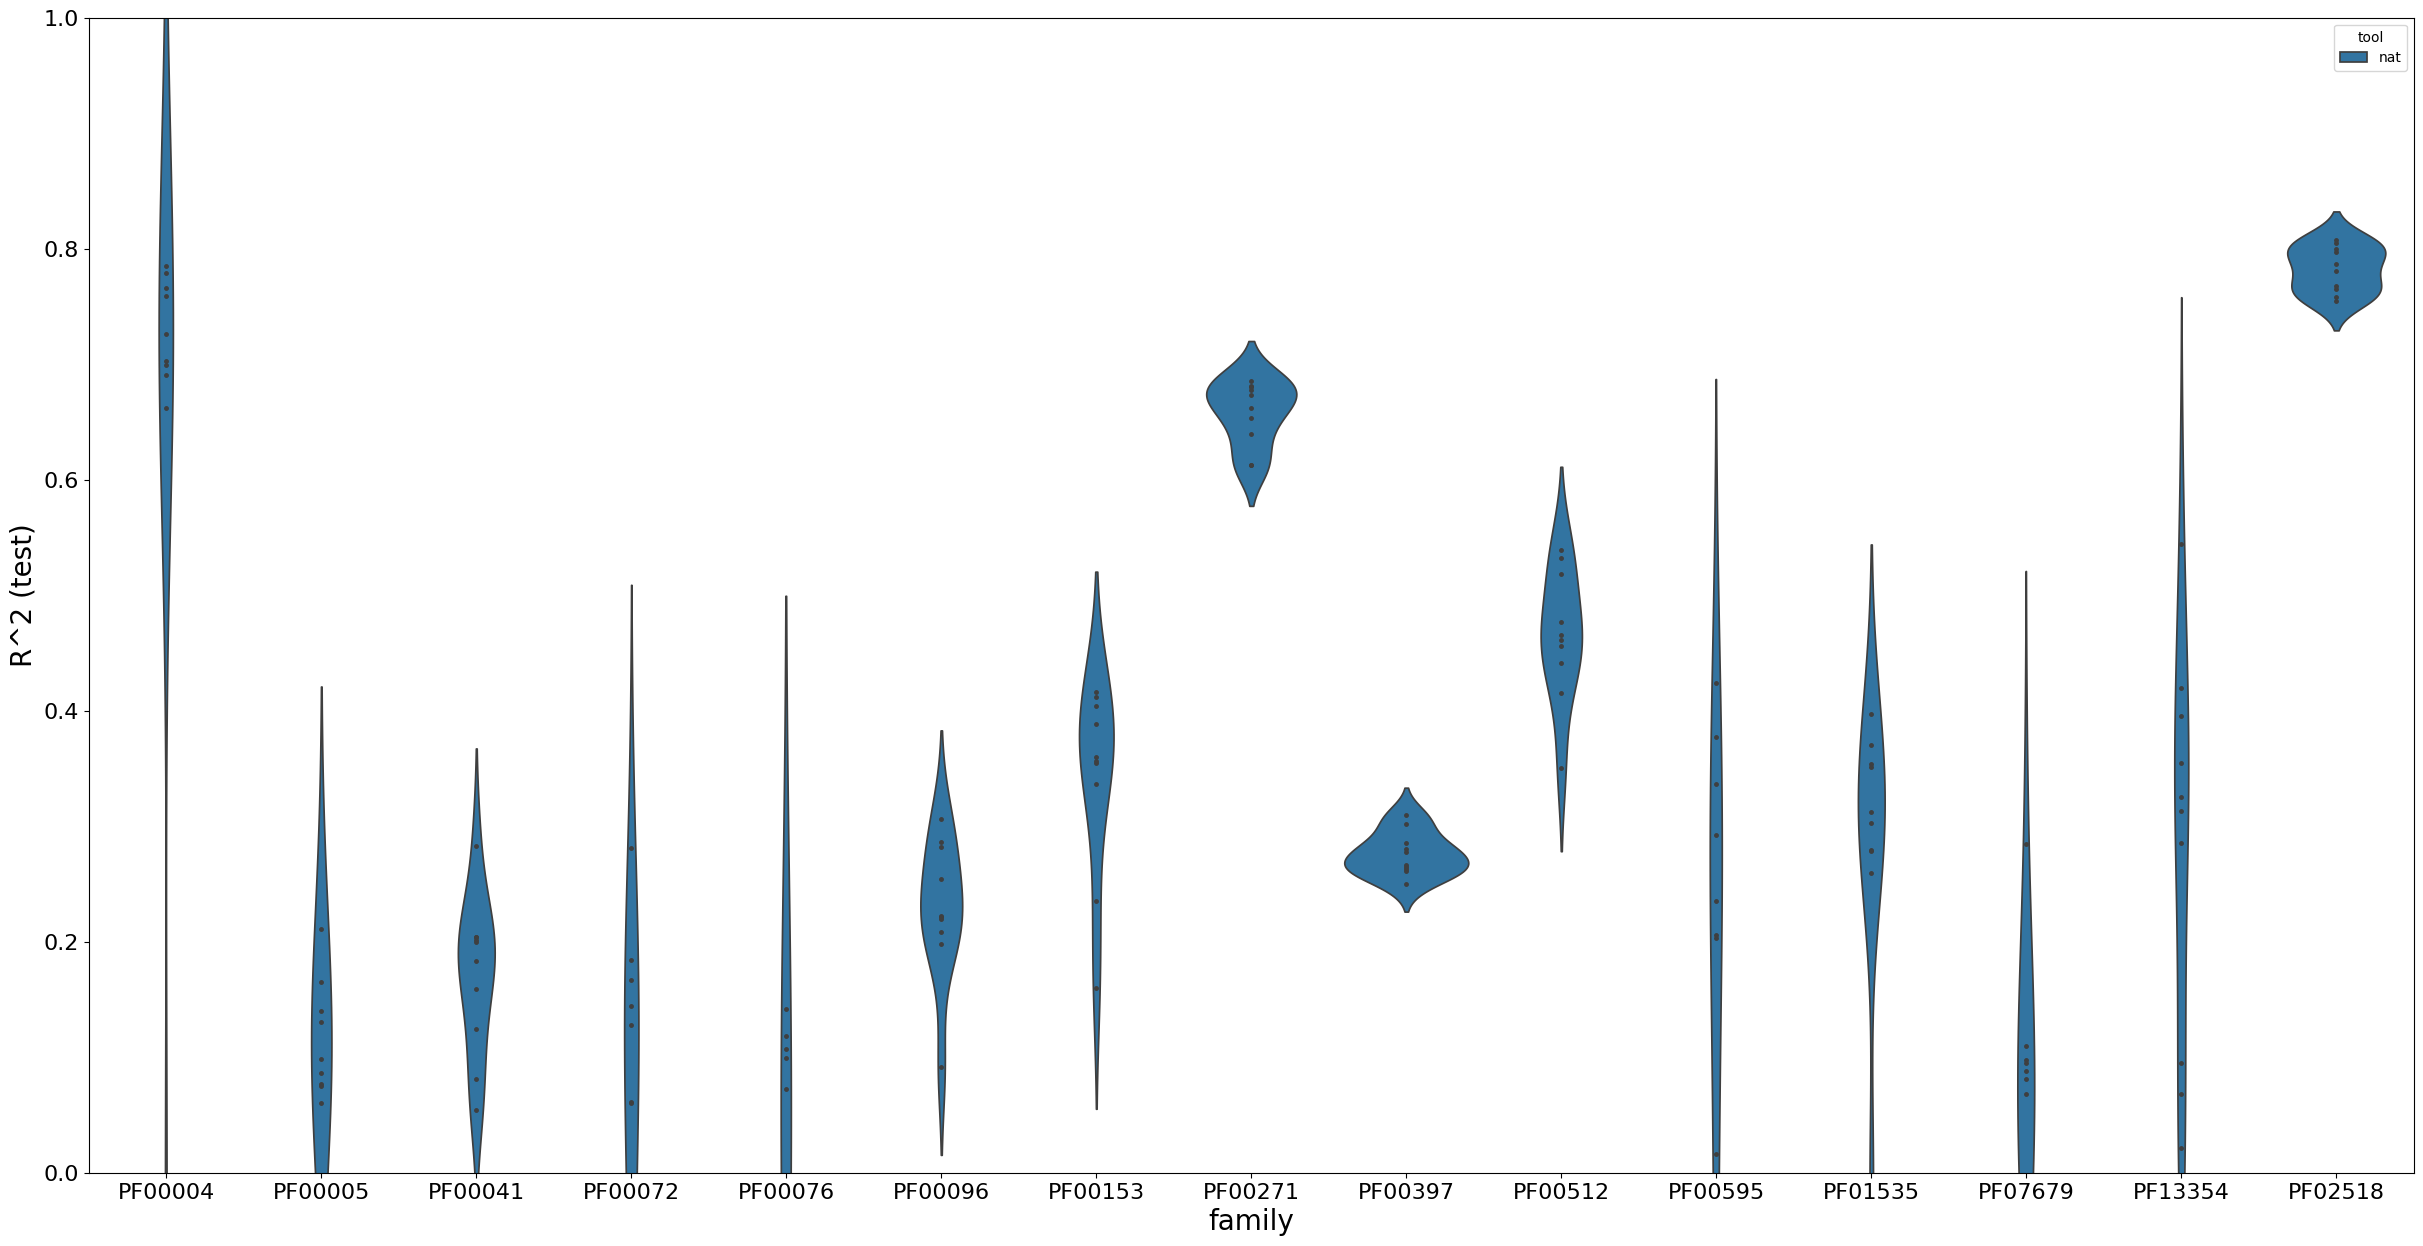

In [13]:
rcParams['figure.figsize'] = 30,15
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)    # fontsize of the tick labels

fig, axes = plt.subplots()

sns.violinplot(data = regr_results_df, x = "family", y = "R^2 (test)", hue = "tool", ax = axes, inner = "point")

axes.set_ylim([0,1])
axes.set_xlabel(axes.get_xlabel(), size = 20)
axes.set_ylabel(axes.get_ylabel(), size = 20)

# axes.set_title("Attention logistic fit to hamming distances (no diagonal)", fontdict={"size":20})

# plt.savefig("r2_logistic_attnfit_ham_dist.png")

In [ ]:


epsilon = 1e-6

def safe_logit(y):
    y = np.clip(y, epsilon, 1 - epsilon)
    return logit(y)

attention_cols = [f"col_attn_{i}" for i in range(144)]
response_col = "ham_dist"

regr_results = {}

regr_results_df = []
    
for family in all_families_train_df["family"].unique():
        
        print(family)

        all_families_train_df_fam = all_families_train_df.loc[all_families_train_df["family"] == family, :].reset_index(drop = True)
        all_families_test_df_fam = all_families_test_df.loc[all_families_test_df["family"] == family, :].reset_index(drop = True)

        for seed_number in all_families_train_df_fam["seed_number"].unique():
              
            all_families_train_df_fam_seed = all_families_train_df.loc[all_families_train_df["seed_number"] == seed_number, :].reset_index(drop = True)
            all_families_test_df_fam_seed = all_families_test_df.loc[all_families_test_df["seed_number"] == seed_number, :].reset_index(drop = True)

            df_train = all_families_train_df_fam_seed[attention_cols + [response_col]]
            df_test = all_families_test_df_fam_seed[attention_cols + [response_col]]

            formula = f"{response_col} ~ " + " + ".join(attention_cols)
            y_train, X_train = dmatrices(formula, df_train, return_type="dataframe")
            y_test, X_test = dmatrices(formula, df_test, return_type="dataframe")

            binom_model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
            binom_model_results = binom_model.fit(maxiter=500, tol=1e-9)

            y_pred_test = binom_model_results.predict(X_test)
            y_pred_train = binom_model_results.predict(X_train)

            y_train = y_train[response_col]
            y_test = y_test[response_col]
            # X_train = all_families_train_df_fam_seed[attention_cols]
            # X_test = all_families_test_df_fam_seed[attention_cols]

            # y_train = all_families_train_df_fam_seed[response_col]
            # y_test = all_families_test_df_fam_seed[response_col]

            # X_train = add_constant(X_train)
            # X_test = add_constant(X_test)

            # logistic_regressor = TransformedTargetRegressor(regressor=LinearRegression(),
            #                                 func=safe_logit, inverse_func=expit)
            
            # logistic_regressor.fit(X_train, y_train)
            # coefs = logistic_regressor.regressor_.coef_

            # y_pred = logistic_regressor.predict(X_test)
            # r2 = r2_score(y_test, y_pred)

            n_samples_train = len(y_train)
            n_samples_test = len(y_test)

            # regr_results[family] = {
            #     "bias": binom_model_results.params[0],
            #     "coeffs": binom_model_results.params.to_numpy()[-n_layers * n_heads:].reshape(n_layers, n_heads),
            #     "y_train": y_train,
            #     "y_pred_train": y_pred_train,
            #     "y_test": y_test,
            #     "y_pred_test": y_pred_test,
            #     "depth": len(df_train) + len(df_test),
            #     "n_rows_train": n_rows_train,
            #     "n_rows_test": n_rows_test,
            #     "RMSE (training)": np.linalg.norm(y_train - y_pred_train) / np.sqrt(n_samples_train),
            #     "RMSE (test)": np.linalg.norm(y_test - y_pred_test) / np.sqrt(n_samples_test),
            #     "MAE (training)": np.sum(np.abs(y_train - y_pred_train)) / n_samples_train,
            #     "MAE (test)": np.sum(np.abs(y_test - y_pred_test)) / n_samples_test,
            #     "R^2 (test)" : r2_score(y_test, y_pred_test),
            #     "Pearson (test)" : pearsonr(y_test[response_col], y_pred_test).statistic
            #     }

            small_inds = y_test <= 0.4
            large_inds = y_test > 0.4

            small_test = y_test[small_inds]
            big_test = y_test[large_inds]

            small_pred_test = y_pred_test[small_inds]
            large_pred_test = y_pred_test[large_inds]
            
            regr_results_df.append({   
                "family":family, 
                "seed_number":seed_number ,
                "RMSE (training)": np.linalg.norm(y_train - y_pred_train) / np.sqrt(n_samples_train),
                "RMSE (test)": np.linalg.norm(y_test - y_pred_test) / np.sqrt(n_samples_test),
                "MAE (training)": np.sum(np.abs(y_train - y_pred_train)) / n_samples_train,
                "MAE (test)": np.sum(np.abs(y_test - y_pred_test)) / n_samples_test,
                "R^2 (test)" : r2_score(y_test, y_pred_test),
                "R^2 (small test)" : r2_score(small_test, small_pred_test),
                "R^2 (large test)" : r2_score(large_test, large_pred_test),
                "Pearson (test)" : pearsonr(y_test, y_pred_test).statistic
                })

    

regr_results_df = pd.DataFrame(regr_results_df)


PF00004


KeyboardInterrupt: 

In [56]:
regr_results_df.to_csv("nat_norm_pat_dist_attention_fit_metrics.tsv", sep = "\t", index = False)

In [ ]:
from sklearn.metrics import r2_score

df_regr_results_hamming_msawise = pd.DataFrame()
for pfam_family in families:

    # if pfam_family == "PF02518":
    #     continue
    
    res = regr_results[pfam_family]
    for key in res:
        exec(f"{key} = res['{key}']")
    n_samples_train = len(y_train)
    n_samples_test = len(y_test)
    df_regr_results_hamming_msawise.loc[pfam_family, "Depth"] = depth
    
    df_regr_results_hamming_msawise.loc[pfam_family, "mean (training)"] = np.mean(y_train)
    df_regr_results_hamming_msawise.loc[pfam_family, "mean (test)"] = np.mean(y_test)
    df_regr_results_hamming_msawise.loc[pfam_family, "std (training)"] = np.std(y_train)
    df_regr_results_hamming_msawise.loc[pfam_family, "std (test)"] = np.std(y_test)
    
    df_regr_results_hamming_msawise.loc[pfam_family, "RMSE (training)"] = np.linalg.norm(y_train - y_pred_train) / np.sqrt(n_samples_train)
    df_regr_results_hamming_msawise.loc[pfam_family, "RMSE (test)"] = np.linalg.norm(y_test - y_pred_test) / np.sqrt(n_samples_test)
    df_regr_results_hamming_msawise.loc[pfam_family, "MAE (training)"] = np.sum(np.abs(y_train - y_pred_train)) / n_samples_train
    df_regr_results_hamming_msawise.loc[pfam_family, "MAE (test)"] = np.sum(np.abs(y_test - y_pred_test)) / n_samples_test
    
    df_regr_results_hamming_msawise.loc[pfam_family, "R^2 (test)"] = r2_score(y_test, y_pred_test)
    pearson = pearsonr(y_test, y_pred_test)[0]
    df_regr_results_hamming_msawise.loc[pfam_family, "Pearson (test)"] = pearson
    df_regr_results_hamming_msawise.loc[pfam_family, "Slope (test)"] = pearson * np.std(y_pred_test) / np.std(y_test)

df_regr_results_hamming_msawise

,Depth,mean (training),mean (test),std (training),std (test),RMSE (training),RMSE (test),MAE (training),MAE (test),R^2 (test),Pearson (test),Slope (test)
PF00004,207.0,0.460015,0.496621,0.180464,0.184537,6.296825e-02,0.080537,4.794712e-02,0.062244,0.809528,0.901149,0.811216
PF00005,55.0,0.571134,0.602637,0.110340,0.156944,3.391046e-02,0.118636,2.667198e-02,0.088346,0.428597,0.782467,0.529392
PF00041,98.0,0.553209,0.545966,0.125533,0.110616,6.705400e-02,0.081140,5.295729e-02,0.062687,0.461928,0.780212,0.846163
PF00072,52.0,0.630471,0.602559,0.138902,0.107052,4.086680e-02,0.126720,3.269930e-02,0.089343,-0.401221,0.636048,0.973103
PF00076,68.0,0.607037,0.678735,0.131238,0.129725,5.056650e-02,0.101143,3.998629e-02,0.078729,0.392111,0.745640,0.850991
PF00096,159.0,0.408810,0.416747,0.141206,0.117642,6.980958e-02,0.075846,5.560109e-02,0.058143,0.584343,0.778210,0.636885
PF00153,160.0,0.625276,0.622517,0.125934,0.112823,6.680219e-02,0.096700,5.332181e-02,0.075529,0.265400,0.615266,0.551453
PF00271,421.0,0.319901,0.331685,0.078978,0.103988,4.159136e-02,0.056620,3.306087e-02,0.040834,0.703529,0.844856,0.638008
PF00397,448.0,0.421681,0.435071,0.146495,0.147971,9.423322e-02,0.104084,7.540887e-02,0.081332,0.505210,0.716123,0.558105
PF00512,265.0,0.489877,0.469785,0.144355,0.138323,7.722614e-02,0.088018,6.121058e-02,0.066307,0.595098,0.793220,0.773122


### Embeddings

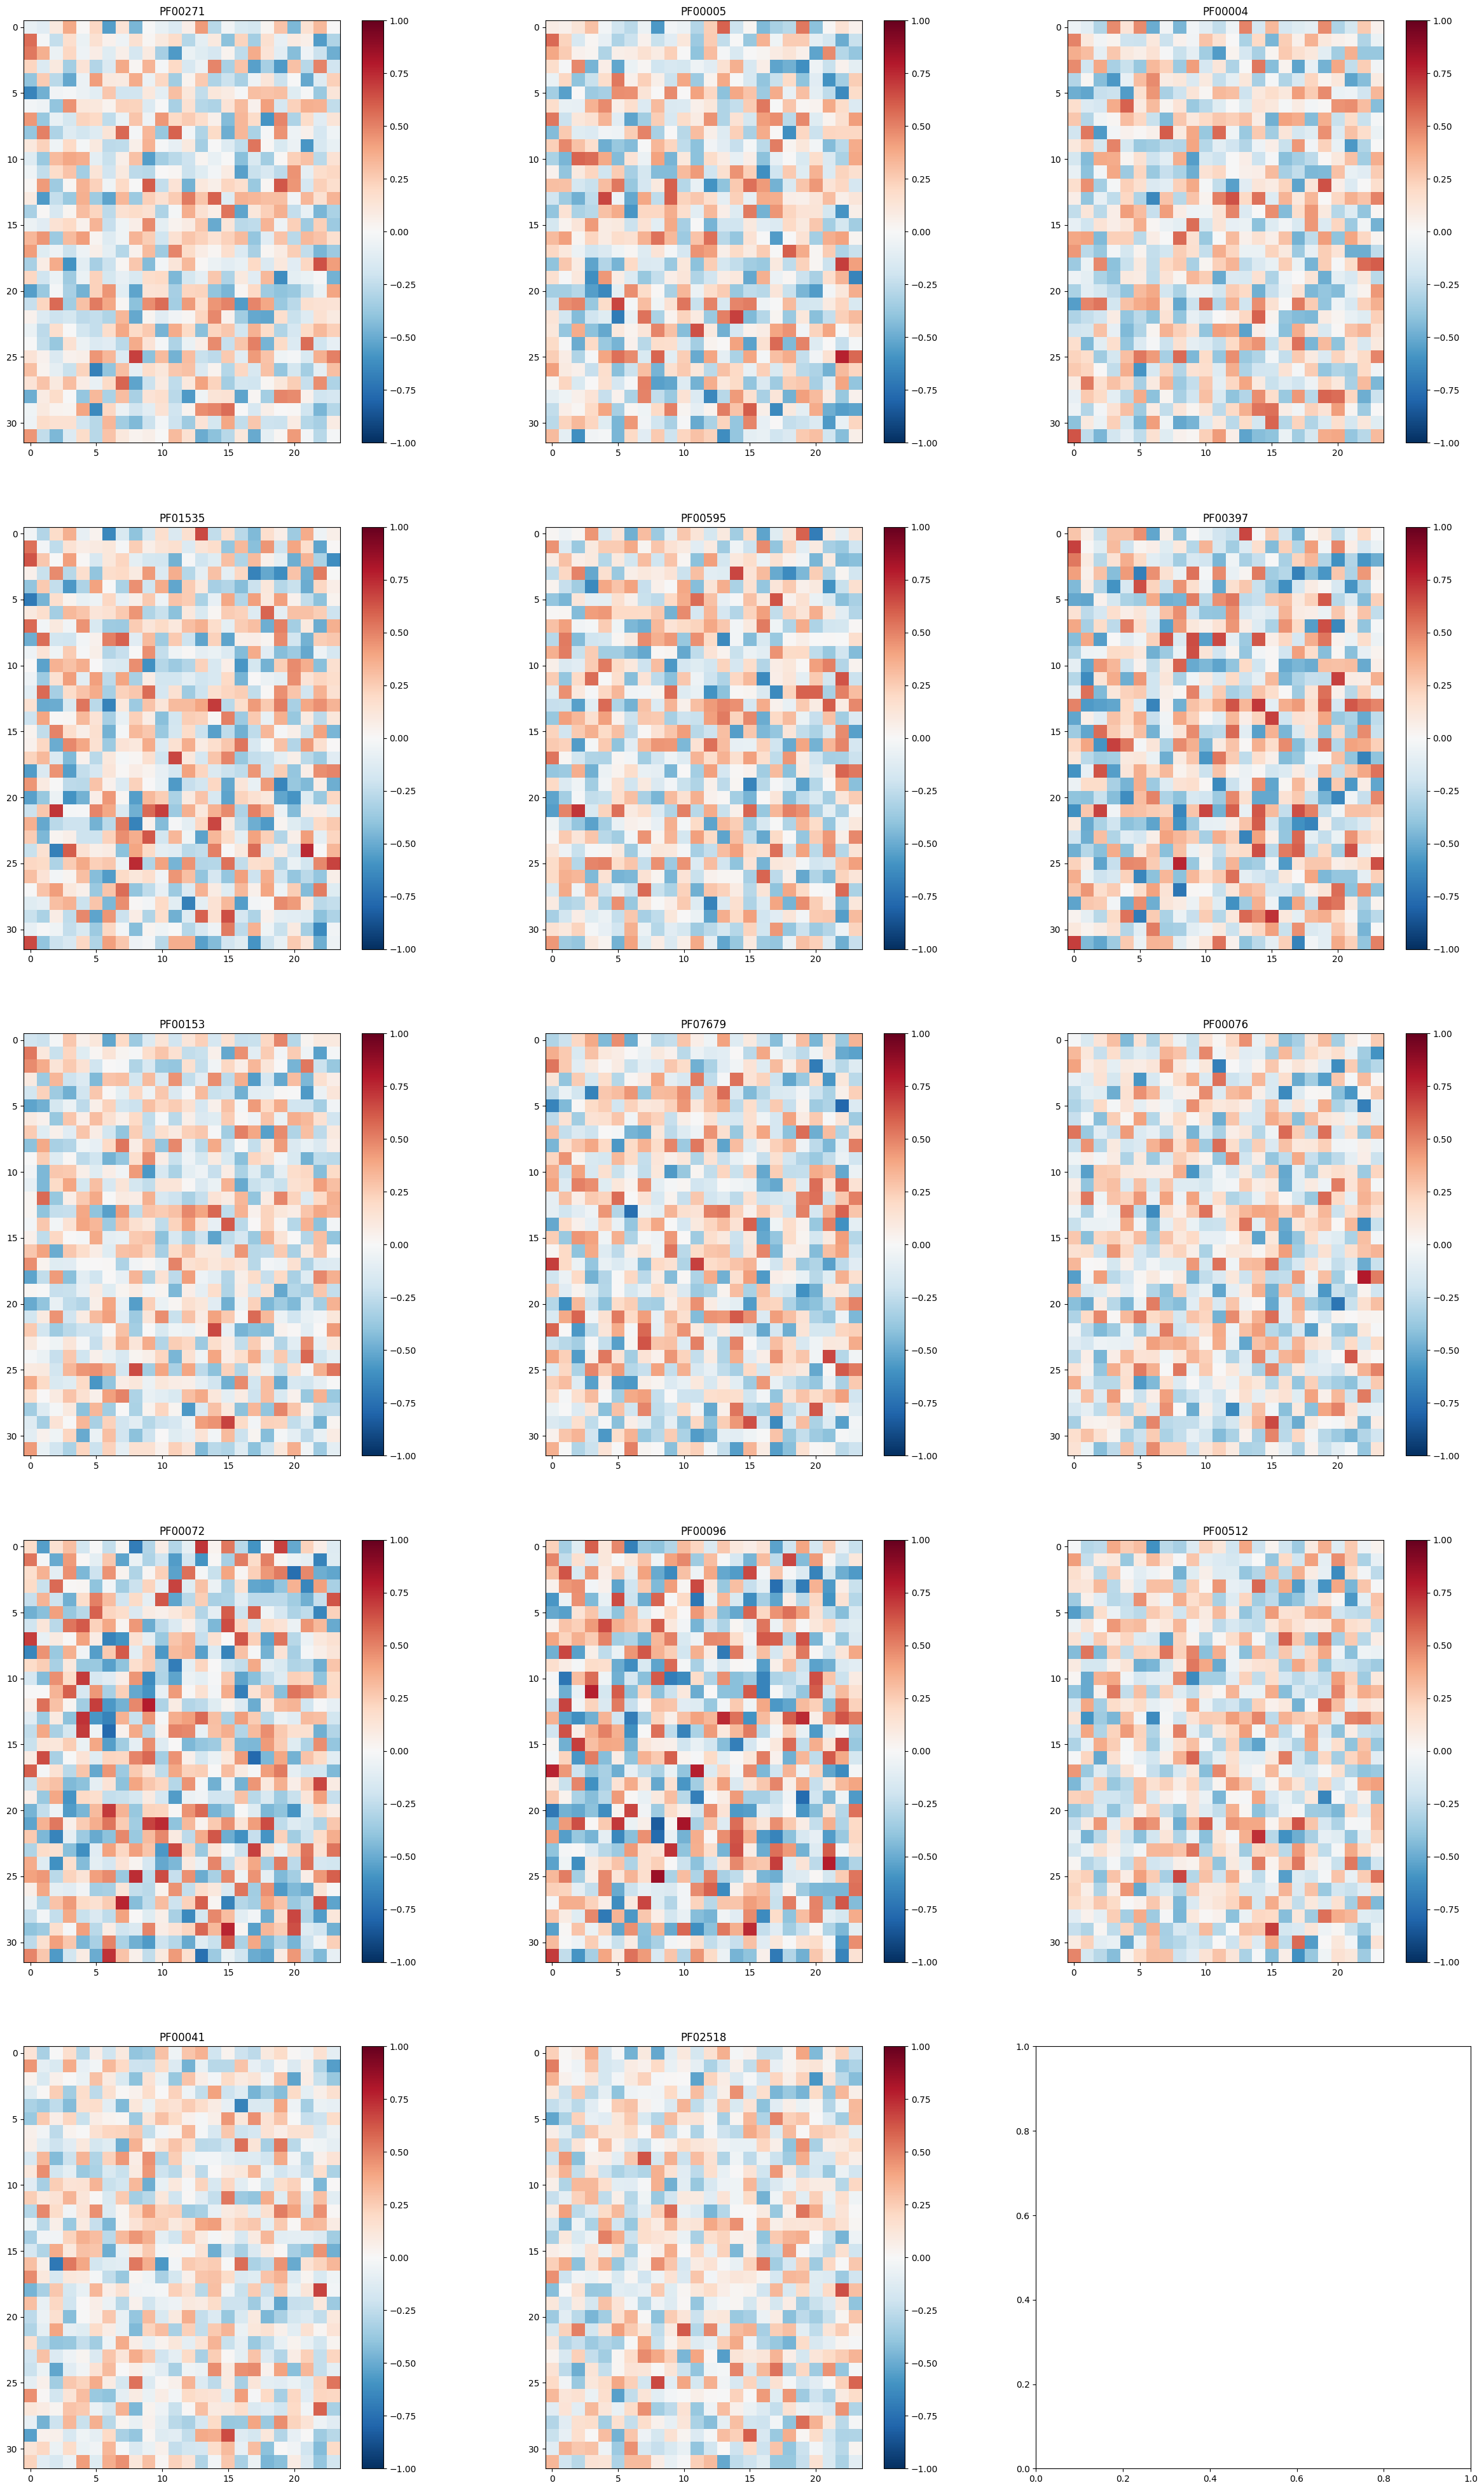

In [12]:
family = "PF00004"
sim_ind = 1
tool = "MSA-1b-logitsprop-static-10-init-seq-0"

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

embed_dim = 768

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

corr_matrix_hmmer_list = []
corr_matrix_stat_list = []
corr_matrix_plddt_list = []
corr_matrix_nat_dist_list = []
corr_matrix_self_dist_list = []
corr_matrix_rmsd_list = []

for k, family in enumerate(families):

    torch.cuda.empty_cache()

    all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["pfam_id"] == family) & 
                                                      (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                      (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3


    if len(all_metrics_dataframe_fam) > 500:
        # random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
        all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

    sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]
    device = "cuda:1" if torch.cuda.is_available() else "cpu"

    _,_, sequences_tensor = batch_converter([sequences])
    sequences_tensor = sequences_tensor.to(device)

    model_output = model(sequences_tensor, need_head_weights=True, repr_layers = [12])
    embeds = model_output["representations"][12][0].cpu().numpy()
    embeds = embeds.mean(axis = 1)

    n_seqs = len(sequences)

    del model_output, sequences_tensor
    torch.cuda.empty_cache()

    embeds_df = pd.DataFrame(embeds, columns = [f"dim_{i}" for i in range(embeds.shape[1])])
    final_df = pd.concat([embeds_df, all_metrics_dataframe_fam], axis = 1)

    corr_matrix_hmmer = np.zeros(embed_dim)
    corr_matrix_stat = np.zeros(embed_dim)
    corr_matrix_plddt = np.zeros(embed_dim)
    corr_matrix_nat_dist = np.zeros(embed_dim)
    corr_matrix_self_dist = np.zeros(embed_dim)
    corr_matrix_rmsd = np.zeros(embed_dim)

    for a in range(len(corr_matrix_hmmer)):

        corr = pearsonr(final_df[f"dim_{a}"], final_df["hmmer_seq_score"]).statistic
        corr_matrix_hmmer[a] = corr

        try:
            corr = pearsonr(final_df[f"dim_{a}"], final_df["stat_energy_scores"]).statistic
            corr_matrix_stat[a] = corr
        except:
            pass

        corr = pearsonr(final_df[f"dim_{a}"], final_df["plddt_scores"]).statistic
        corr_matrix_plddt[a] = corr

        corr = pearsonr(final_df[f"dim_{a}"], final_df["min_natural_ham_dist_seed"]).statistic
        corr_matrix_nat_dist[a] = corr

        corr = pearsonr(final_df[f"dim_{a}"], final_df["max_self_ham_distance"]).statistic
        corr_matrix_self_dist[a] = corr

        corr = pearsonr(final_df[f"dim_{a}"], final_df["rmsd"]).statistic
        corr_matrix_rmsd[a] = corr

    corr_matrix_hmmer = np.reshape(corr_matrix_hmmer, newshape = (32,24), order = "C")
    corr_matrix_stat = np.reshape(corr_matrix_stat, newshape = (32,24), order = "C")
    corr_matrix_plddt = np.reshape(corr_matrix_plddt, newshape = (32,24), order = "C")
    corr_matrix_nat_dist = np.reshape(corr_matrix_nat_dist, newshape = (32,24), order = "C")
    corr_matrix_self_dist = np.reshape(corr_matrix_self_dist, newshape = (32,24), order = "C")
    corr_matrix_rmsd = np.reshape(corr_matrix_rmsd, newshape = (32,24), order = "C")

    corr_matrix_hmmer_list.append(corr_matrix_hmmer)
    corr_matrix_stat_list.append(corr_matrix_stat)
    corr_matrix_plddt_list.append(corr_matrix_plddt)
    corr_matrix_nat_dist_list.append(corr_matrix_nat_dist)
    corr_matrix_self_dist_list.append(corr_matrix_self_dist)
    corr_matrix_rmsd_list.append(corr_matrix_rmsd)

    im = axes[i][j].imshow(corr_matrix_hmmer, vmin = -1, vmax = 1, cmap = "RdBu_r")
    plt.colorbar(im, ax=axes[i][j])
    axes[i][j].set_title(f"{family}")

In [13]:
mean_hmmer_corr = np.stack(corr_matrix_hmmer_list).mean(axis=0)
mean_stat_corr = np.stack(corr_matrix_stat_list).mean(axis=0)
mean_plddt_corr = np.stack(corr_matrix_plddt_list).mean(axis=0)
mean_nat_dist_corr = np.stack(corr_matrix_nat_dist_list).mean(axis=0)
mean_self_dist_corr = np.stack(corr_matrix_self_dist_list).mean(axis=0)
mean_rmsd_corr = np.stack(corr_matrix_rmsd_list).mean(axis=0)

Text(0.5, 1.0, 'mean_rmsd_corr')

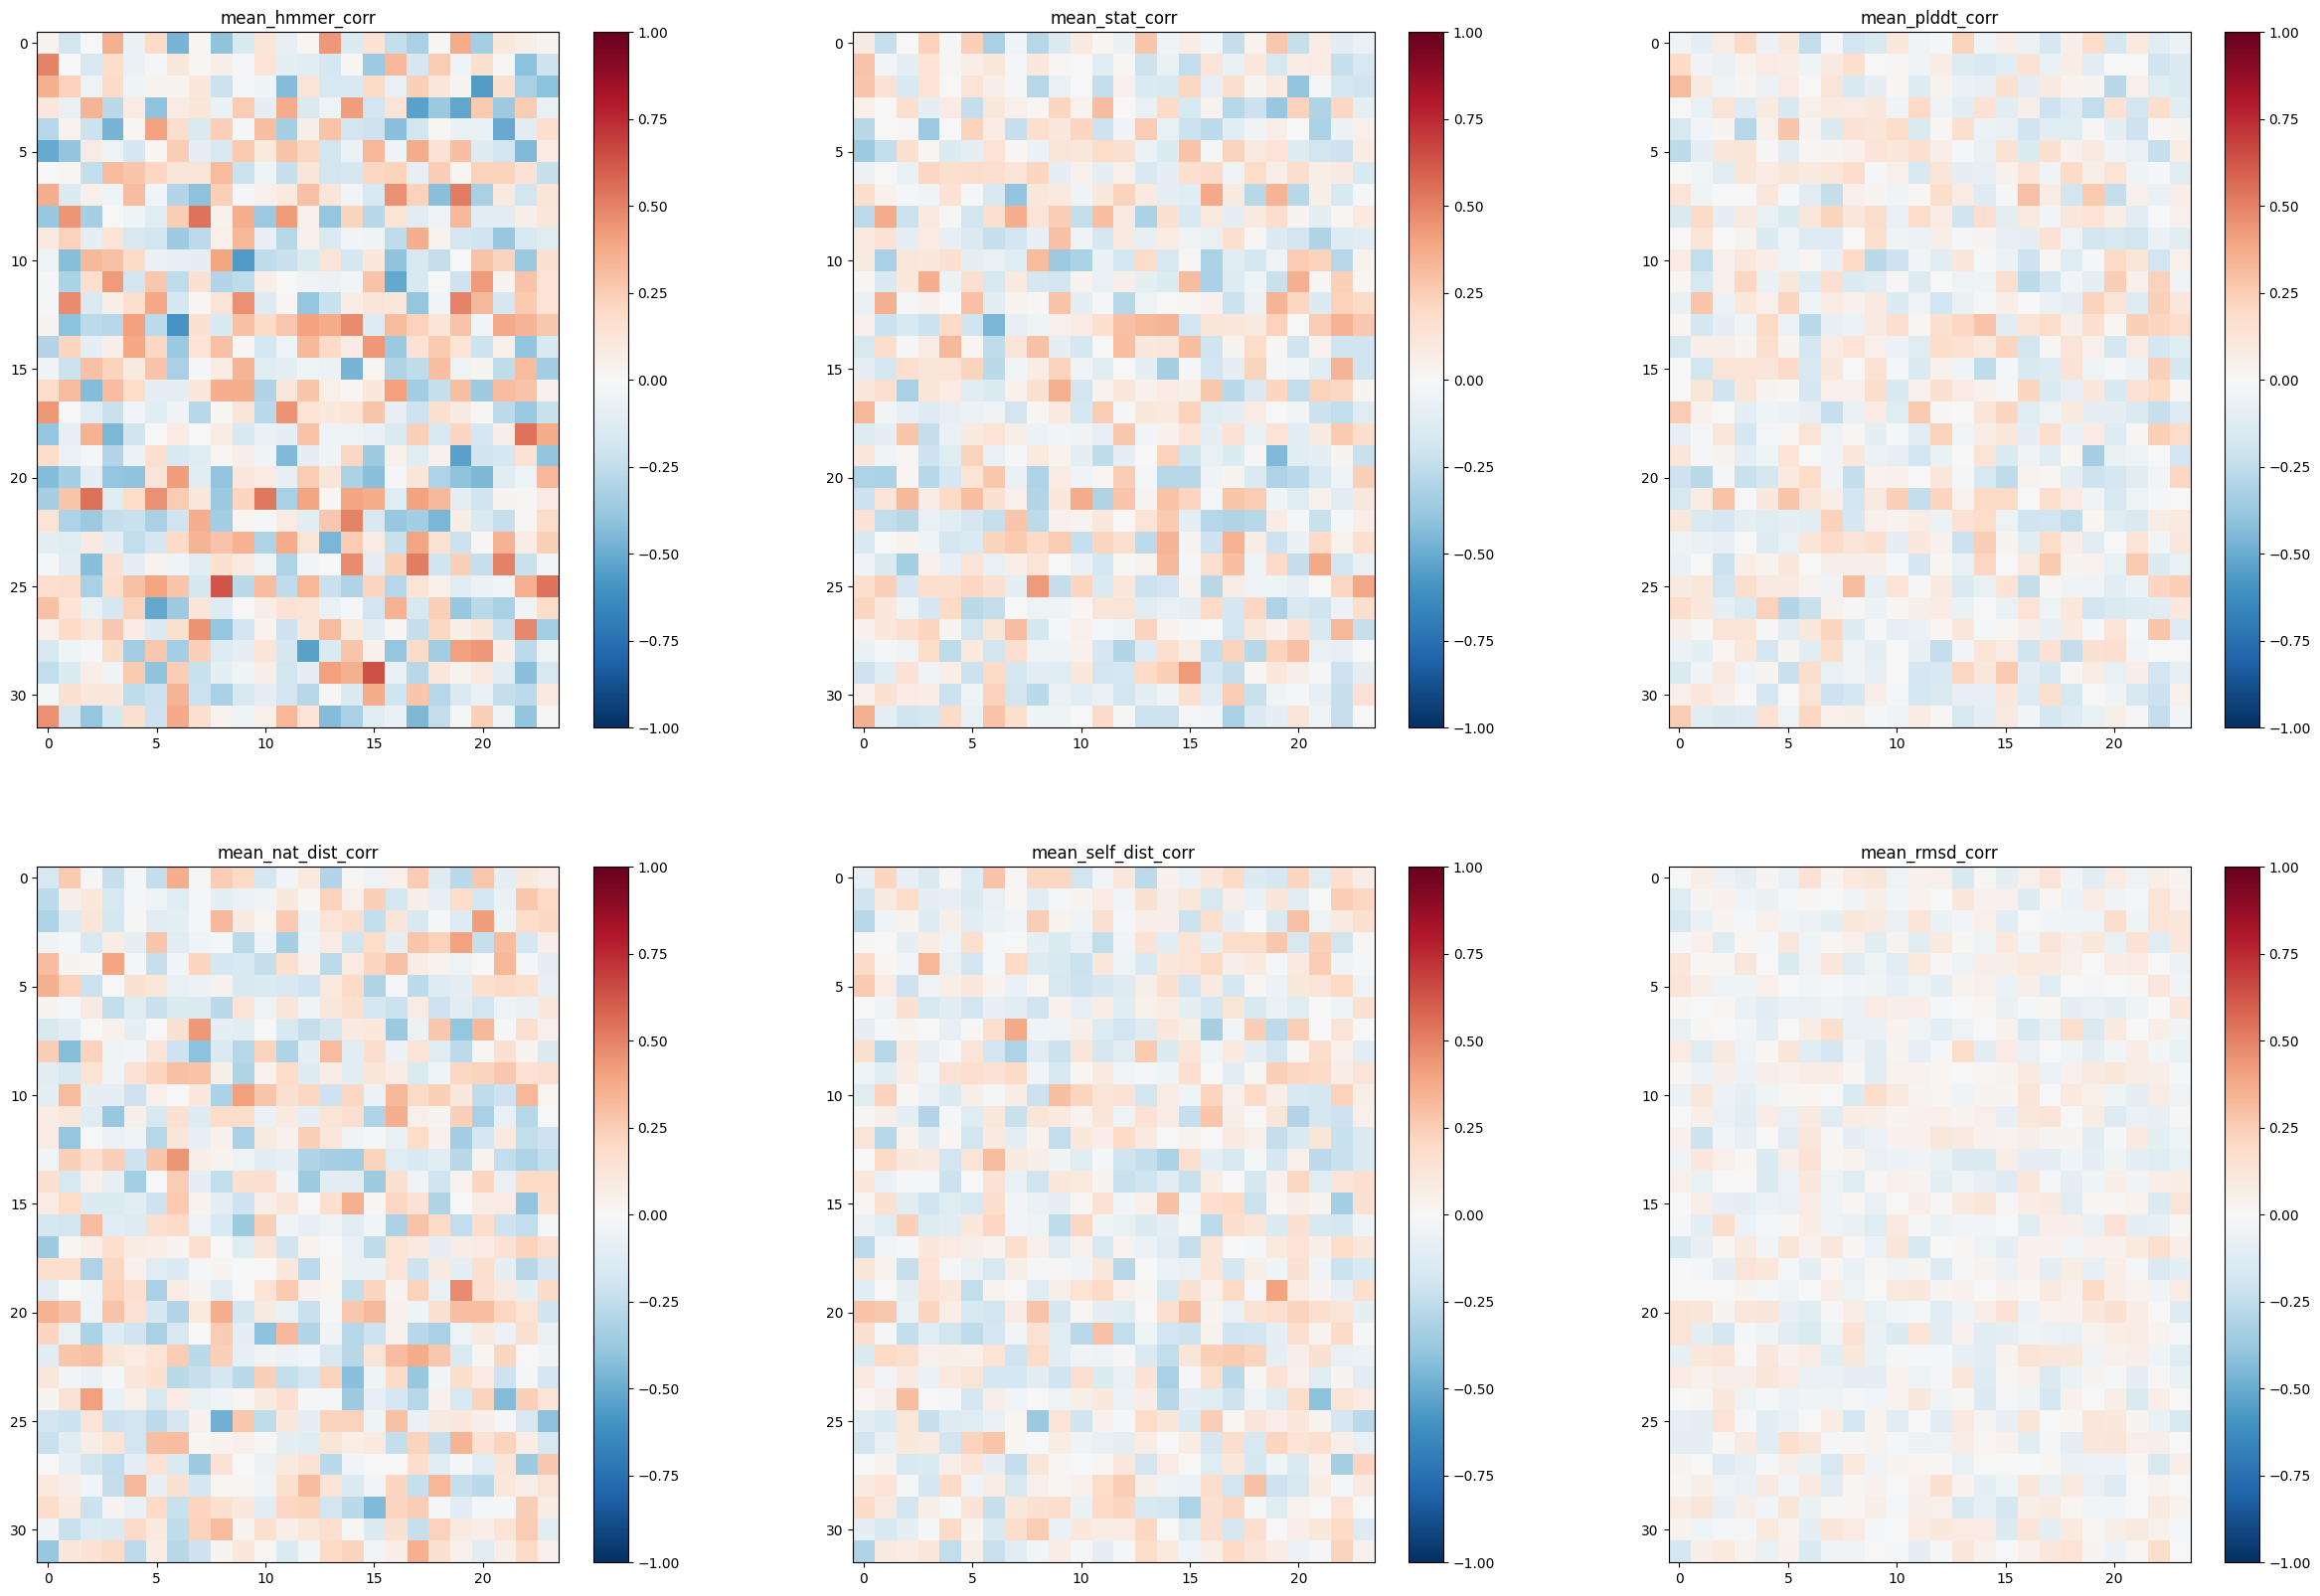

In [14]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

im = axes[0][0].imshow(mean_hmmer_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][0])
axes[0][0].set_title(f"mean_hmmer_corr")

im = axes[0][1].imshow(mean_stat_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][1])
axes[0][1].set_title(f"mean_stat_corr")

im = axes[0][2].imshow(mean_plddt_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][2])
axes[0][2].set_title(f"mean_plddt_corr")

im = axes[1][0].imshow(mean_nat_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][0])
axes[1][0].set_title(f"mean_nat_dist_corr")

im = axes[1][1].imshow(mean_self_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][1])
axes[1][1].set_title(f"mean_self_dist_corr")

im = axes[1][2].imshow(mean_rmsd_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][2])
axes[1][2].set_title(f"mean_rmsd_corr")

Text(0.5, 0.9, 'pearson_corr = 0.90')

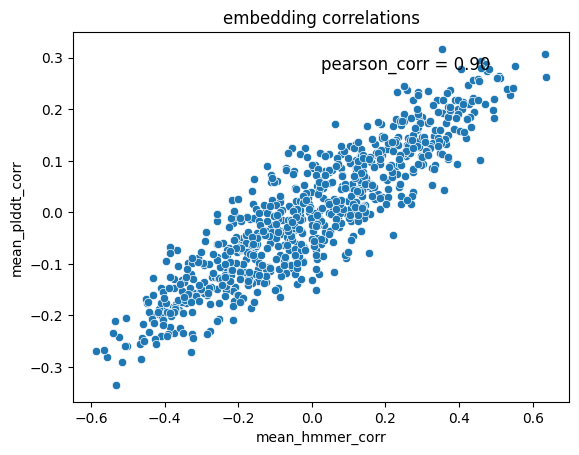

In [16]:
sns.scatterplot(x =mean_hmmer_corr.flatten(), y=mean_plddt_corr.flatten())
plt.xlabel("mean_hmmer_corr")
plt.ylabel("mean_plddt_corr")
plt.title("embedding correlations")

pearson_corr = pearsonr(x =mean_hmmer_corr.flatten(), y=mean_plddt_corr.flatten())
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.5,0.9), xycoords = "axes fraction", fontsize = 12)

### ESM2 Attentions

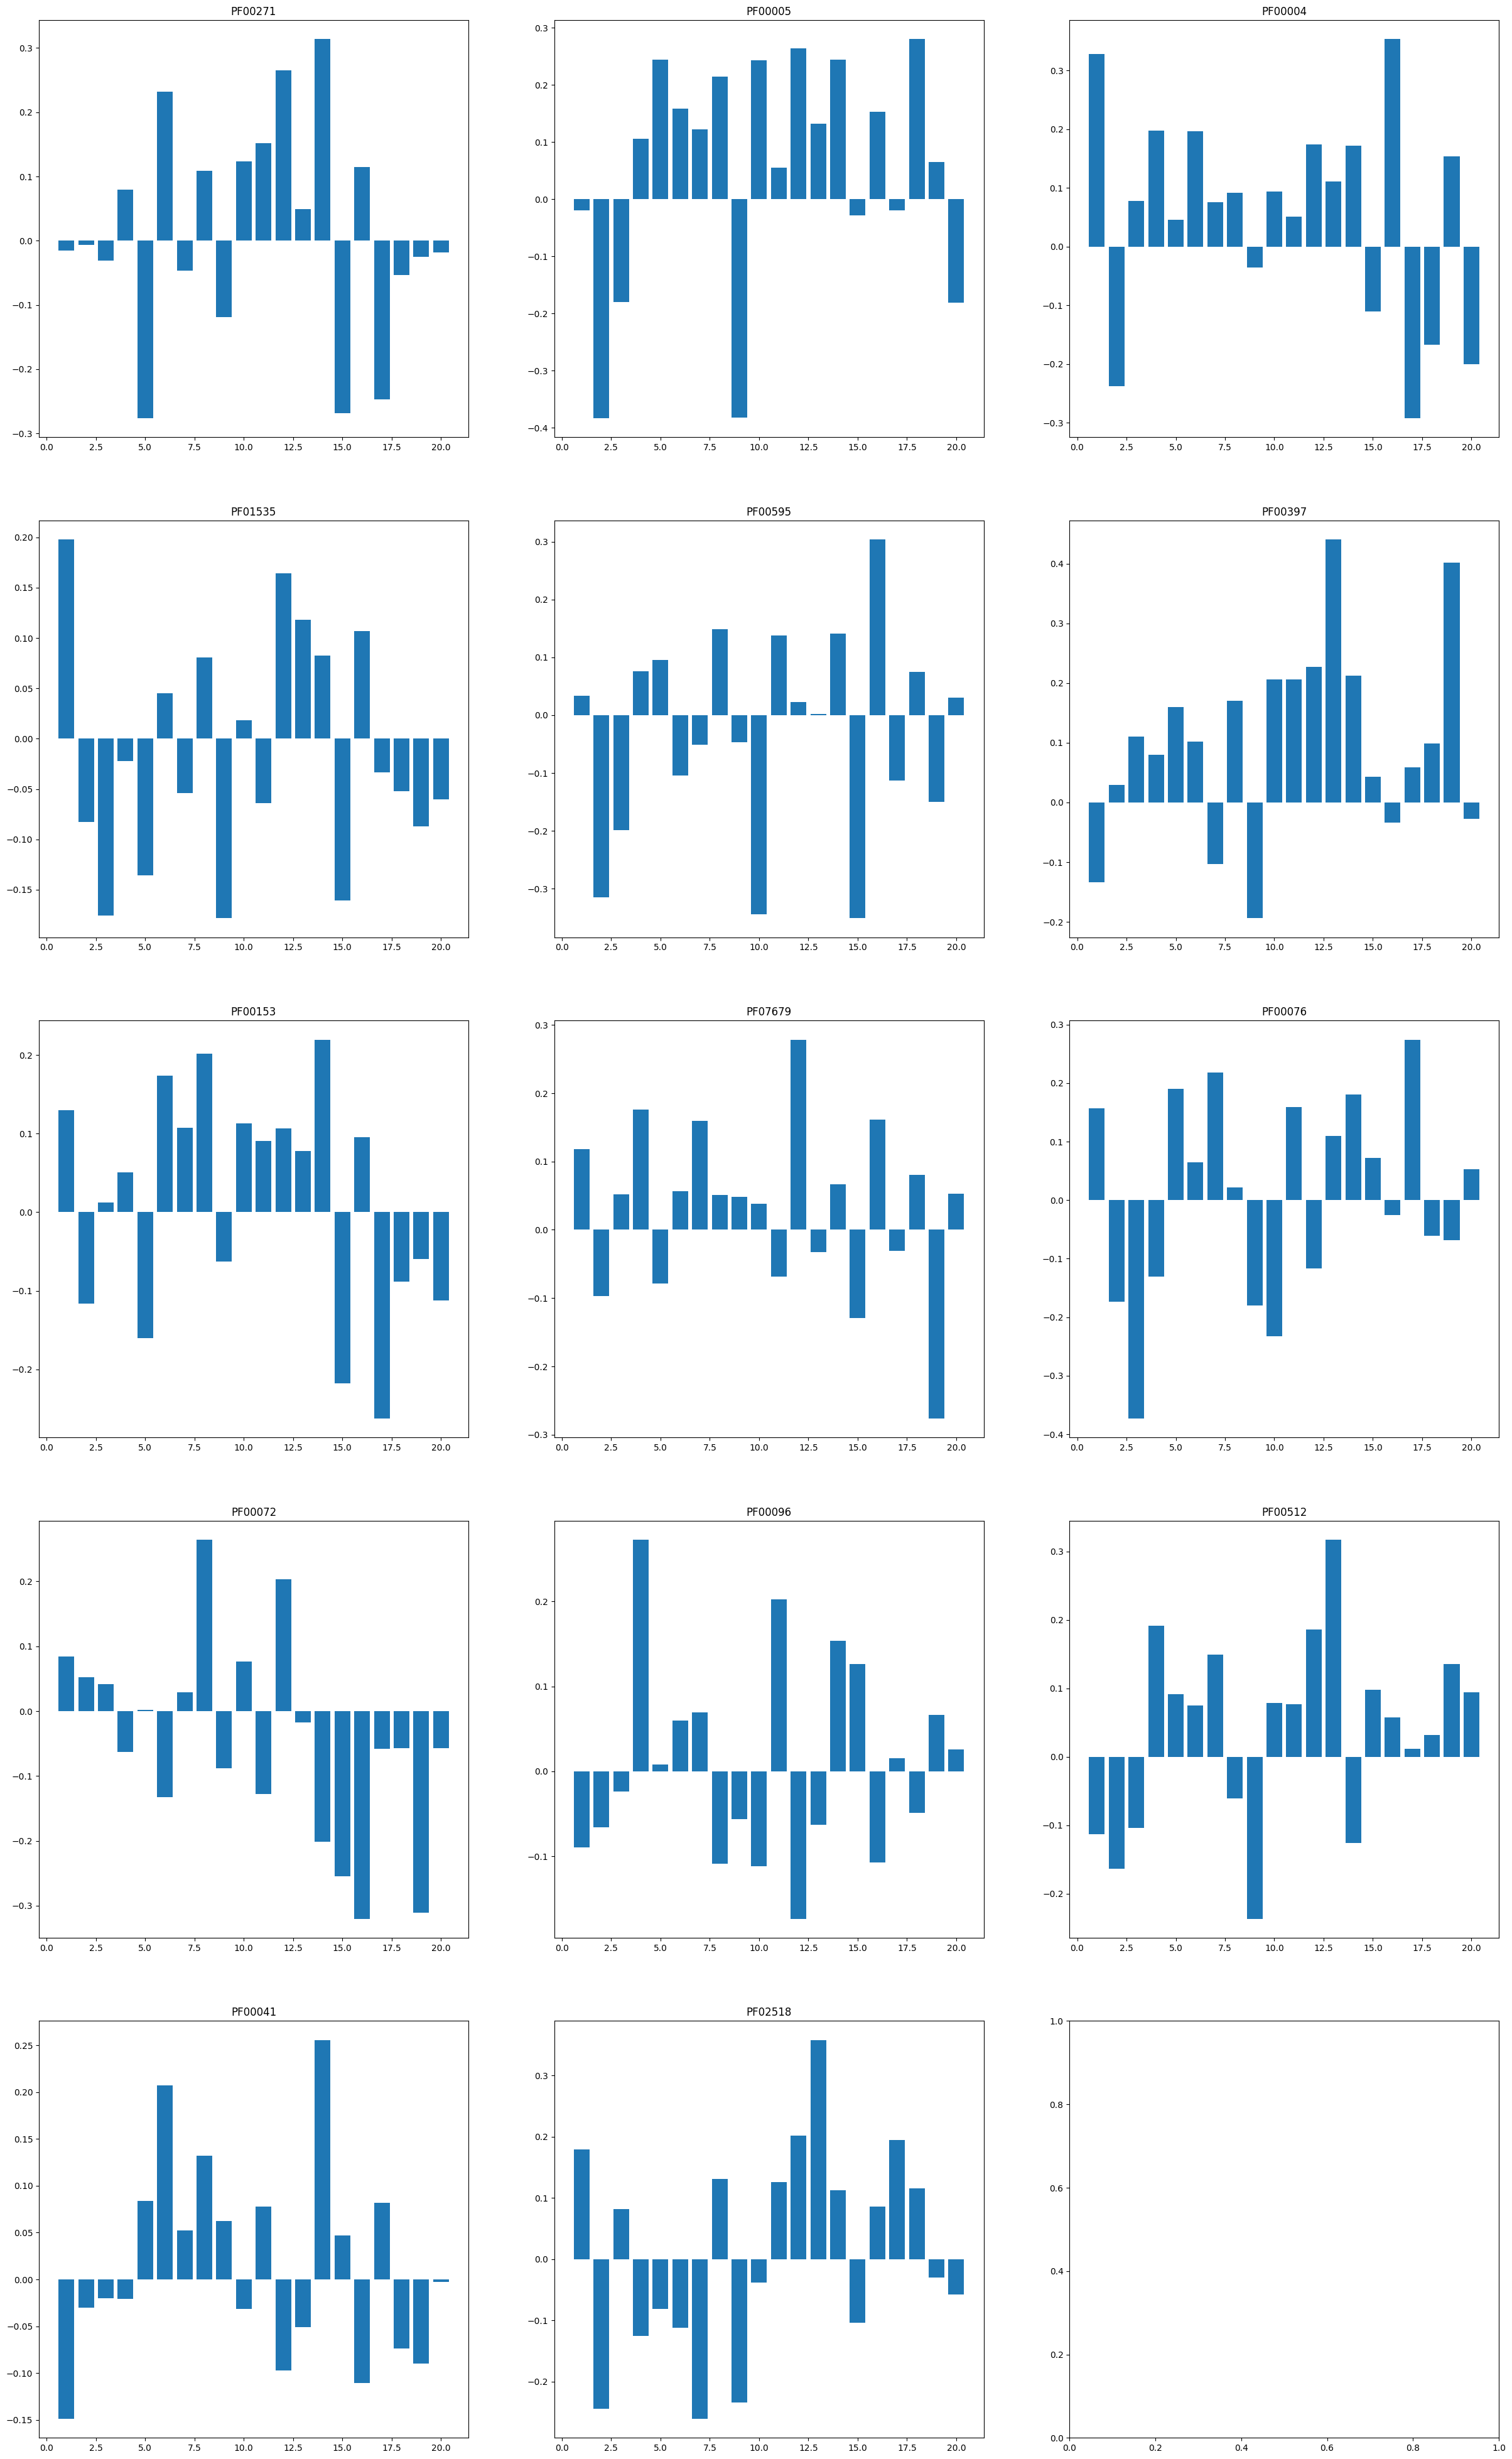

In [42]:
family = "PF00004"
sim_ind = 1
tool = "MSA-1b-logitsprop-static-10-init-seq-0"

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

from transformers import EsmForMaskedLM, EsmTokenizer

model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = EsmTokenizer.from_pretrained(model_name)
model = EsmForMaskedLM.from_pretrained(model_name, output_attentions=True)
model = model.to(device)

model.eval()

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

corr_matrix_hmmer_list = []
corr_matrix_stat_list = []
corr_matrix_plddt_list = []
corr_matrix_nat_dist_list = []
corr_matrix_self_dist_list = []
corr_matrix_rmsd_list = []

for k, family in enumerate(families):

    torch.cuda.empty_cache()

    all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["pfam_id"] == family) & 
                                                      (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                      (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3


    sequences = list(all_metrics_dataframe_fam["sequence"])
    device = "cuda:1" if torch.cuda.is_available() else "cpu"

    inputs = tokenizer(sequences, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions[0]

    # max_attn = attentions.mean(axis = [2]).max(axis = 2).values.cpu().numpy()
    mean_attn = attentions.mean(axis = [2])

    def entropy(x, dim=-1, eps=1e-12):
    # Normalize to make it a probability distribution
        p = x / (x.sum(dim=dim, keepdim=True) + eps)

        # Avoid log(0) by adding small epsilon
        log_p = torch.log(p + eps)

        # Compute entropy: -sum(p * log(p))
        H = - (p * log_p).sum(dim=dim)
        return H

    entropy_attn = entropy(mean_attn, dim=2).cpu().numpy()

    del outputs, inputs, attentions
    torch.cuda.empty_cache()

    max_attn_df = pd.DataFrame(entropy_attn, columns = [f"col_attn_{i}" for i in range(entropy_attn.shape[1])])
    final_df = pd.concat([max_attn_df, all_metrics_dataframe_fam], axis = 1)

    corr_matrix_hmmer = np.zeros(20)
    corr_matrix_stat = np.zeros(20)
    corr_matrix_plddt = np.zeros(20)
    corr_matrix_nat_dist = np.zeros(20)
    corr_matrix_self_dist = np.zeros(20)
    corr_matrix_rmsd = np.zeros(20)

    for a in range(len(corr_matrix_hmmer)):

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["hmmer_seq_score"]).statistic
        corr_matrix_hmmer[a] = corr

        try:
            corr = pearsonr(final_df[f"col_attn_{a}"], final_df["stat_energy_scores"]).statistic
            corr_matrix_stat[a] = corr
        except:
            pass

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["plddt_scores"]).statistic
        corr_matrix_plddt[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["min_natural_ham_dist_seed"]).statistic
        corr_matrix_nat_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["max_self_ham_distance"]).statistic
        corr_matrix_self_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["rmsd"]).statistic
        corr_matrix_rmsd[a] = corr

    corr_matrix_hmmer_list.append(corr_matrix_hmmer)
    corr_matrix_stat_list.append(corr_matrix_stat)
    corr_matrix_plddt_list.append(corr_matrix_plddt)
    corr_matrix_nat_dist_list.append(corr_matrix_nat_dist)
    corr_matrix_self_dist_list.append(corr_matrix_self_dist)
    corr_matrix_rmsd_list.append(corr_matrix_rmsd)

    axes[i][j].bar(x = range(1,21), height = corr_matrix_hmmer)
    axes[i][j].set_title(f"{family}")

In [43]:
mean_hmmer_corr = np.stack(corr_matrix_hmmer_list).mean(axis=0)
mean_stat_corr = np.stack(corr_matrix_stat_list).mean(axis=0)
mean_plddt_corr = np.stack(corr_matrix_plddt_list).mean(axis=0)
mean_nat_dist_corr = np.stack(corr_matrix_nat_dist_list).mean(axis=0)
mean_self_dist_corr = np.stack(corr_matrix_self_dist_list).mean(axis=0)
mean_rmsd_corr = np.stack(corr_matrix_rmsd_list).mean(axis=0)

Text(0.5, 1.0, 'mean_rmsd_corr')

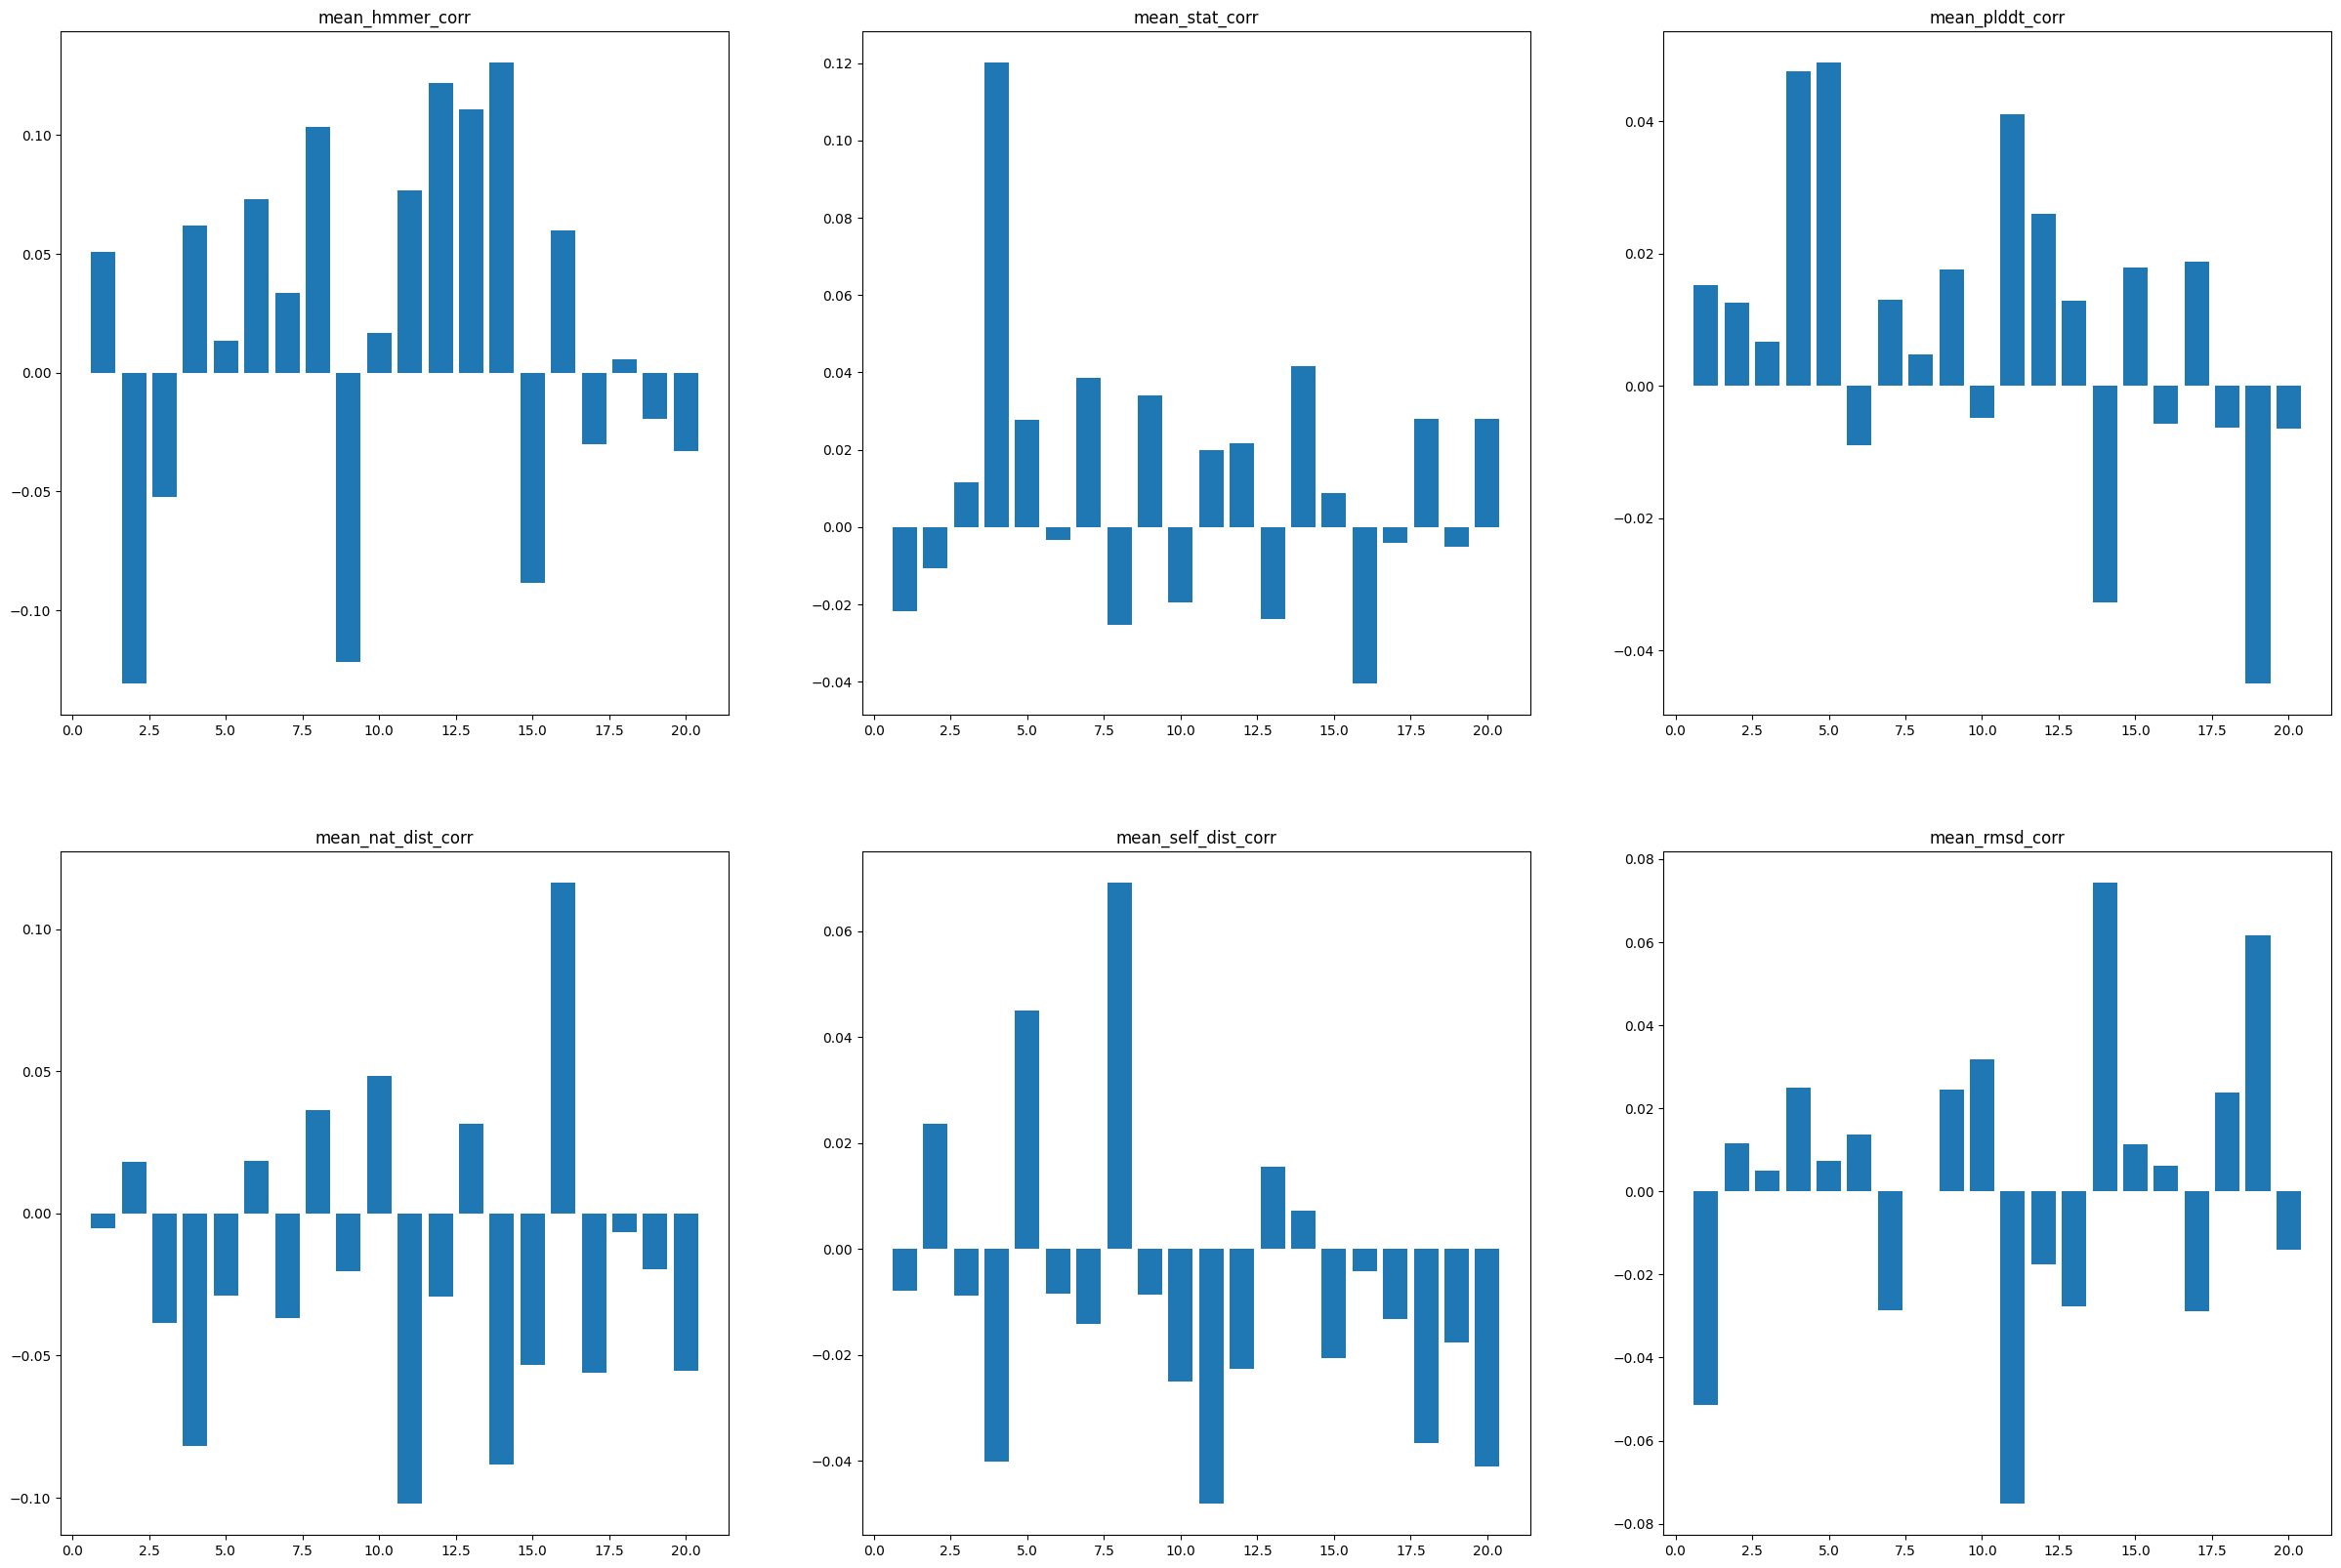

In [44]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

axes[0][0].bar(x = range(1,21), height = mean_hmmer_corr)
axes[0][0].set_title(f"mean_hmmer_corr")

axes[0][1].bar(x = range(1,21), height = mean_stat_corr)
axes[0][1].set_title(f"mean_stat_corr")

axes[0][2].bar(x = range(1,21), height = mean_plddt_corr)
axes[0][2].set_title(f"mean_plddt_corr")

axes[1][0].bar(x = range(1,21), height = mean_nat_dist_corr)
axes[1][0].set_title(f"mean_nat_dist_corr")

axes[1][1].bar(x = range(1,21), height = mean_self_dist_corr)
axes[1][1].set_title(f"mean_self_dist_corr")

axes[1][2].bar(x = range(1,21), height = mean_rmsd_corr)
axes[1][2].set_title(f"mean_rmsd_corr")

In [4]:
import torch
import esm

sequence = "MRKDFVANVSHELKTPITSIKGFTETLLDGMEDKEALSEFLSIILKESERLQSLVQDLLDLSKIEQ"

model = esm.pretrained.esmfold_v1()
model = model.eval().cuda()

with torch.no_grad():
        pdb_file = model.infer_pdb(sequence)

with open("nat_PF00512.pdb", "w") as f:
    f.write(pdb_file)

In [2]:
from Bio import SeqIO
from scripts.aux_msa_functions import *
import subprocess

nat_seed_sequences = [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse("./data/protein-families-msa-seed/PF00004_seed.fasta", "fasta")]

array_MSA = np.array([list(sequence[1]) for sequence in nat_seed_sequences])
len_MSA = array_MSA.shape[1]
n_seqs = array_MSA.shape[0] 

bootstrap_MSA =  np.empty_like(array_MSA)
column_sample_inds = np.random.choice(range(len_MSA), len_MSA, replace=True)

bootstrap_MSA = array_MSA[:,column_sample_inds]
bootstrap_MSA = [(f'seq{i}', ''.join(bootstrap_MSA[i])) for i in range(n_seqs)]

bootstrap_MSA_path = "bootstrap_tree.fasta"

Seq_tuples_to_fasta(bootstrap_MSA, bootstrap_MSA_path)

In [6]:
column_sample_inds

array([ 52, 110, 120,  98, 110, 130, 111, 113,  55,   7,  87,  30,   8,
        84,  77,  16, 116,   2,  75,  96,  66, 112,   8,  85,  96, 126,
       116,  53,  52,   5, 105,  94,  42,  51,  11,  17, 104,   6,  90,
        38,  96,  14,  16,  87,   4,  11,   2,  83,  85,  17,  77,  60,
        23,  17,  39, 102,  51, 111,  19,  16,  81,  93,  50,  89,  26,
        97, 115,  34, 115,  19,  89,  48, 111, 105,  56,  77,   2, 104,
        13,  76,  52, 129, 101, 128,  29,  14, 124,  55,  23,  12,  21,
         9,  20,  55,  81,  63, 118, 102, 104,  58,  54,  26,  56,  56,
        62,  23,  38,  90,   5,  43, 112,  21,  25,  97,  21,  92,  31,
        47, 109,  86,  21,  25,  82,   1, 120,  44,  91,   8,  96,   6,
        49,  37])